In [62]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from pathlib import Path
import json
import datetime
import re

In [63]:
root = Path('..')
data = Path('data')
dataframe = Path('clean_data.pkl')

df = pd.read_pickle(root/data/dataframe)

In [64]:
df.head()

,title,sales_series,retail_price,release_date,brand,highest_value,pre_release_peak,roi_pct,current_value,is_above_retail,pre_release_premium_pct,days_to_peak,lowest_value_post_release,hype_decay_pct,price_volatility
0,Jordan 1 LowMidnight Navy Neutral Grey,"[{'xValue': '2025-03-13T00:00:00.000Z', 'yValu...",125.0,2025-04-20,Jordan,172,137,37.600000,113.0,False,9.600000,291.0,89.0,34.302326,19.869864
1,Jordan 1 Retro High OGShattered Backboard (2025),"[{'xValue': '2025-06-26T00:00:00.000Z', 'yValu...",180.0,2025-08-23,Jordan,172,266,-4.444444,125.0,False,47.777778,1.0,123.0,27.325581,9.656303
2,Jordan 1 Retro High OG SPFragment x Union LA V...,"[{'xValue': '2026-02-01T00:00:00.000Z', 'yValu...",205.0,2026-02-27,Jordan,302,1500,47.317073,234.0,True,631.707317,1.0,220.0,22.516556,18.590009
3,Jordan 1 Retro HighVirgil Abloh Archive Alaska,"[{'xValue': '2026-03-06T00:00:00.000Z', 'yValu...",230.0,2026-04-03,Jordan,645,2000,180.434783,459.0,True,769.565217,2.0,454.0,28.837209,40.916143
4,Jordan 1 Retro Low OGBanned,"[{'xValue': '2026-04-09T00:00:00.000Z', 'yValu...",145.0,2026-05-02,Jordan,145,334,0.000000,95.0,False,130.344828,0.0,91.0,34.482759,12.444709


# Variable Dictionary

| Variable | Type | Description |
|---|---|---|
| `title` | string | Product title/name (sneaker model) as it appears in the original source. |
| `sales_series` | list[dict] | Time series of prices with structure `[{'xValue': iso_date, 'yValue': price}, ...]`. Includes both pre-release (speculation) and post-release data points. |
| `retail_price` | float | Official retail price (launch price). |
| `release_date` | datetime | Official release date of the product. |
| `brand` | string | Normalized brand extracted from the title (e.g. `Yeezy`, `Nike`, `Adidas`, `Jordan`, etc.). |
| `highest_value` | float | Maximum price reached **using only post-release data** (excludes pre-release speculation). |
| `pre_release_peak` | float | Maximum price reached **before release**, reflecting the level of speculation/hype prior to the official launch. `0` if there is no pre-release data. |
| `roi_pct` | float | Percentage return on investment: `(highest_value - retail_price) / retail_price * 100`. Indicates the potential gain if resold at the post-release peak price. `0` if `retail_price` is invalid. |
| `current_value` | float | Most recent price recorded in `sales_series` (last chronological point across the entire series, pre and post). |
| `is_above_retail` | bool | Indicates whether `current_value` exceeds `retail_price` (`True`/`False`). |
| `pre_release_premium_pct` | float | Pre-release speculative premium percentage: `(pre_release_peak - retail_price) / retail_price * 100`. `0` if there was no recorded speculation or `retail_price` is invalid. |
| `days_to_peak` | int | Number of days between `release_date` and the date `highest_value` was reached (always ≥ 0, since it is measured on post-release data). |
| `lowest_value_post_release` | float | Minimum price recorded **after** release. |
| `hype_decay_pct` | float | Percentage drop in price from the peak to the current value: `(highest_value - current_value) / highest_value * 100`. Higher values indicate the initial hype "deflated" over time. |
| `price_volatility` | float | Standard deviation of post-release prices. Measures how unstable/volatile the resale price is. `0` if there is only one or no post-release data points. |

# univariate EDA

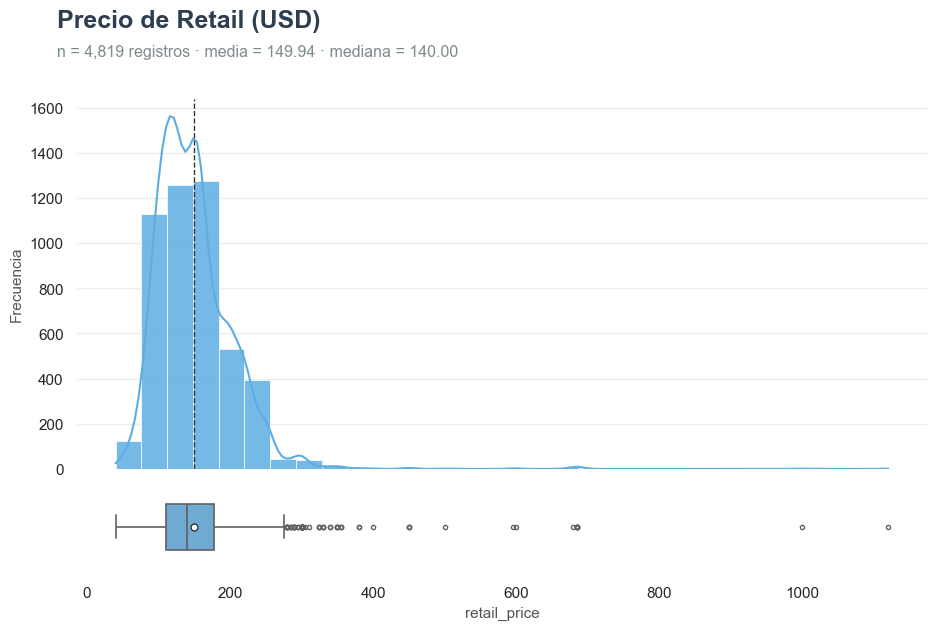

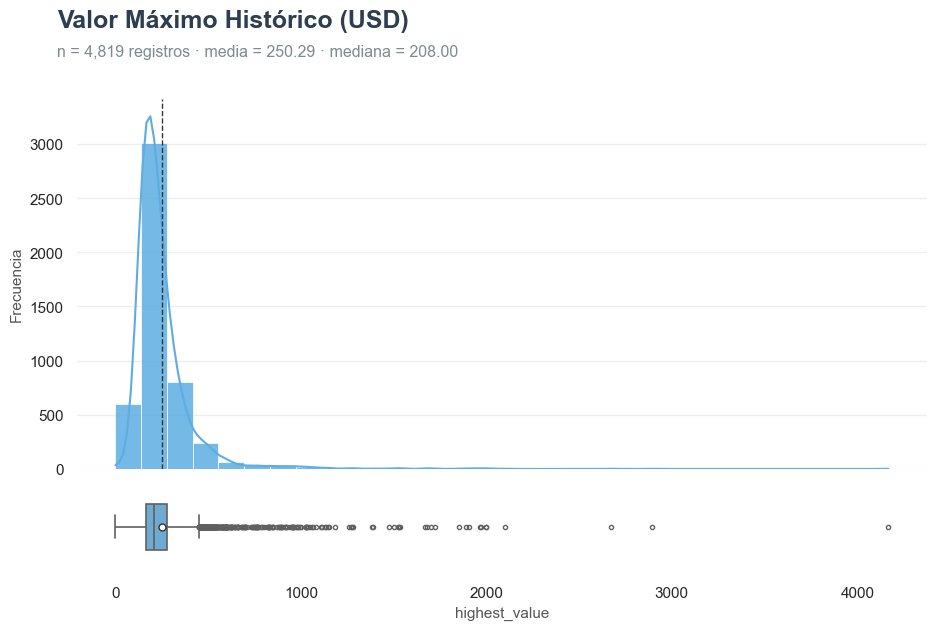

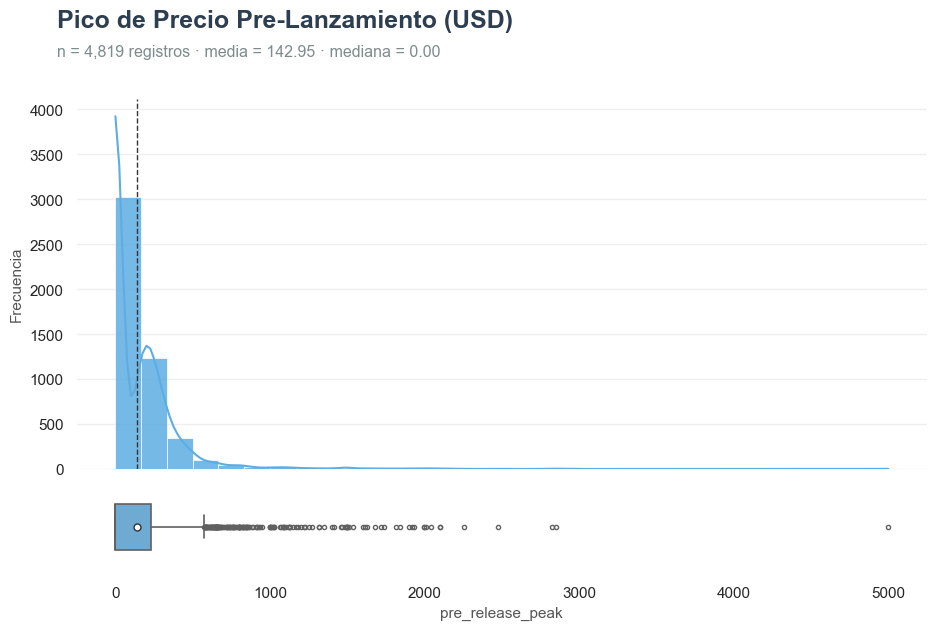

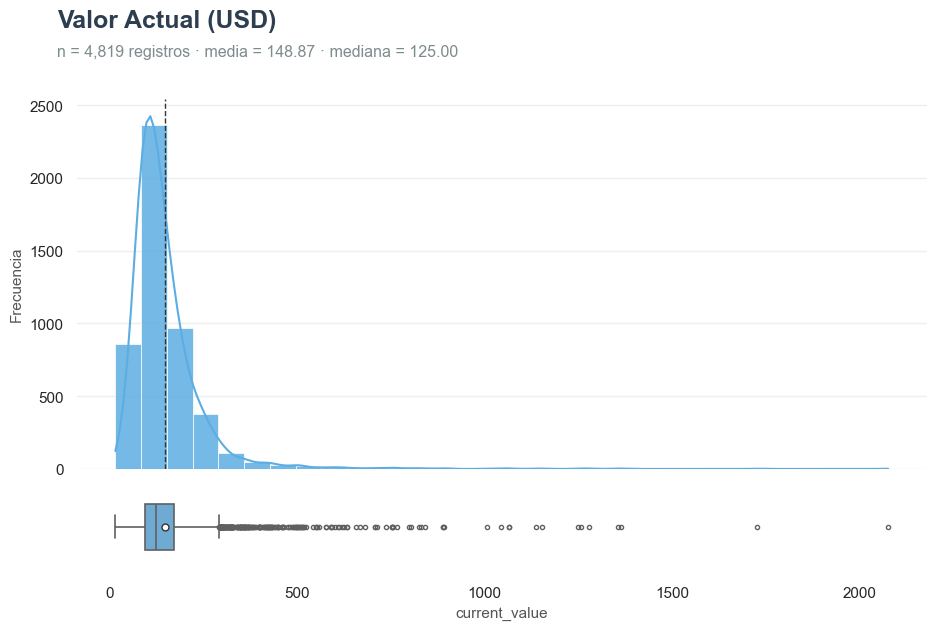

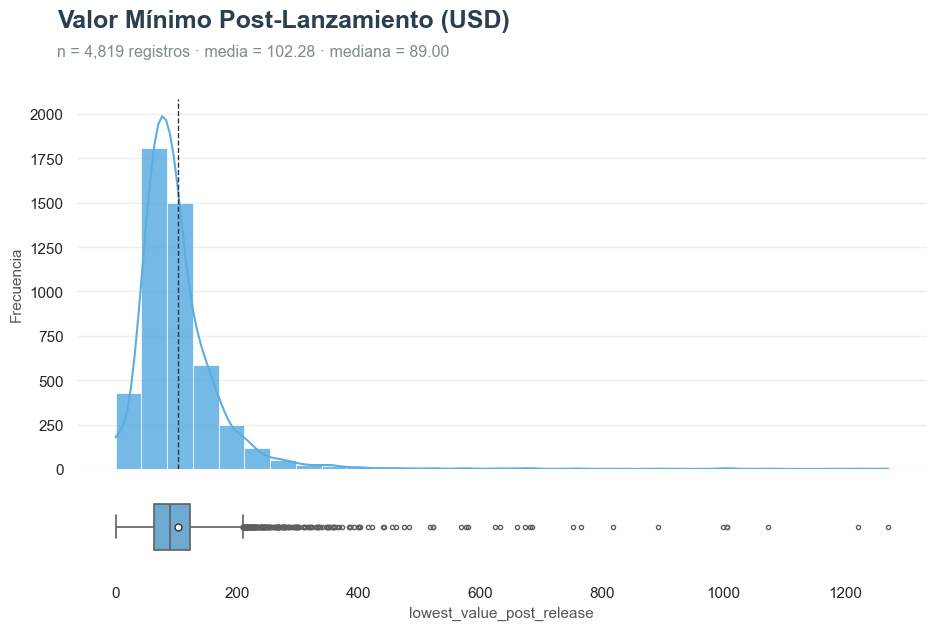

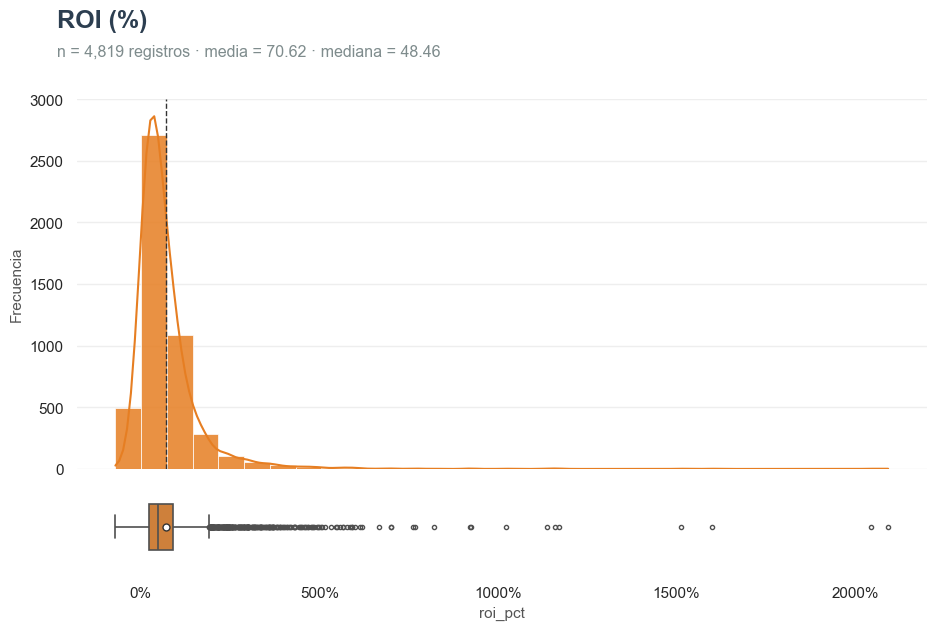

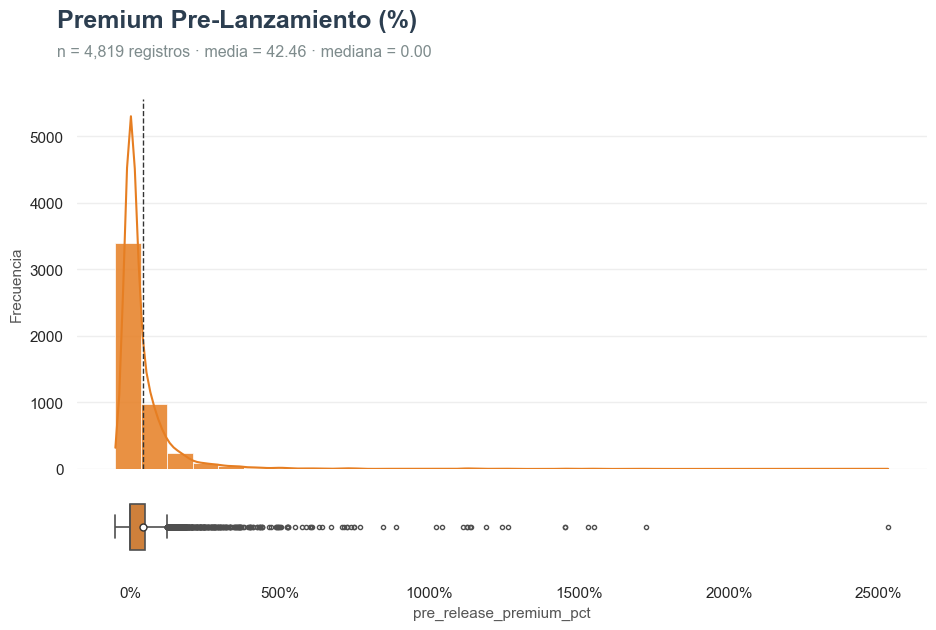

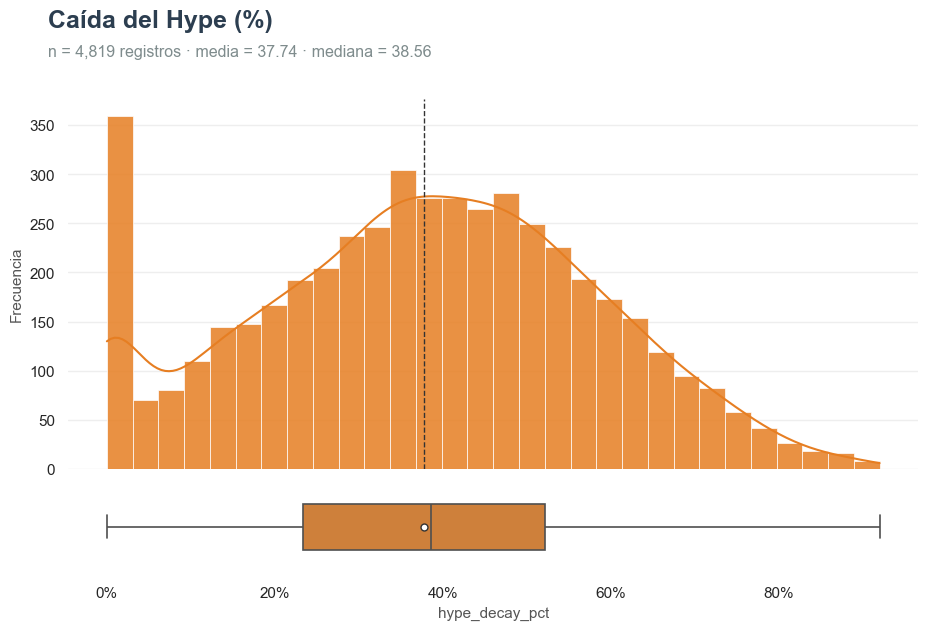

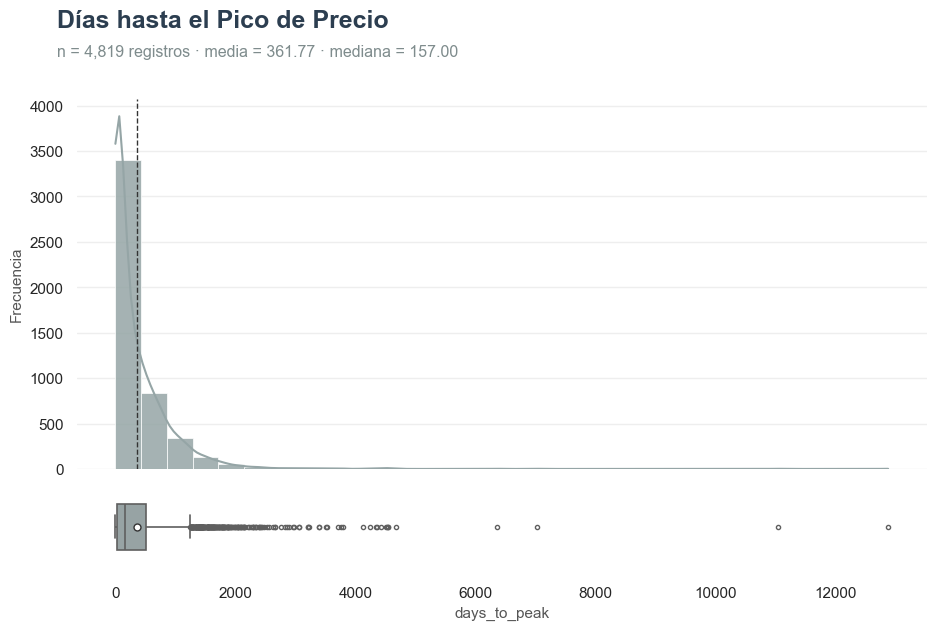

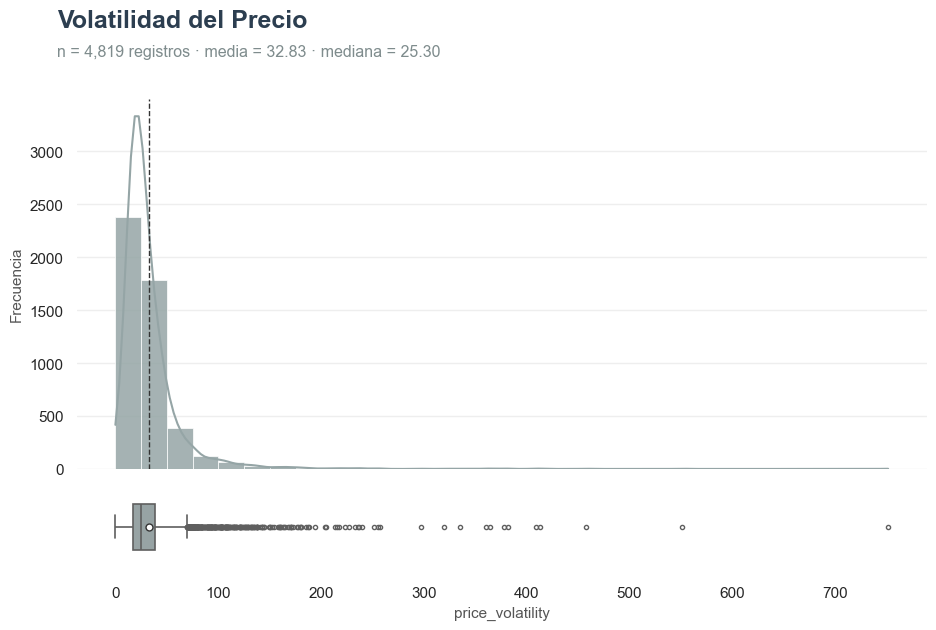

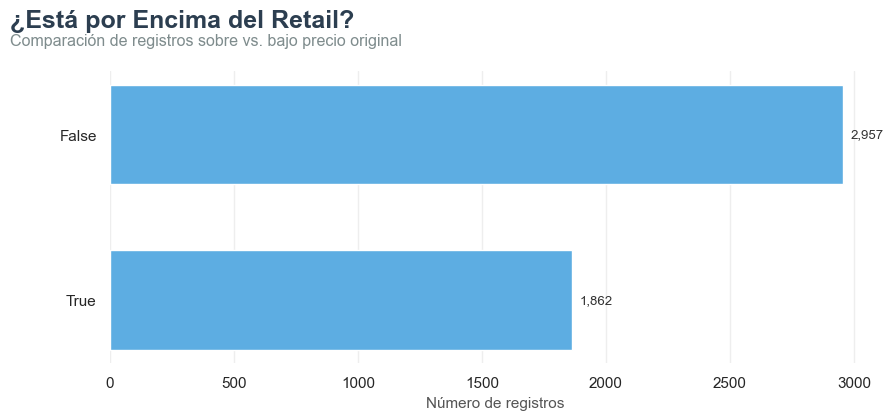

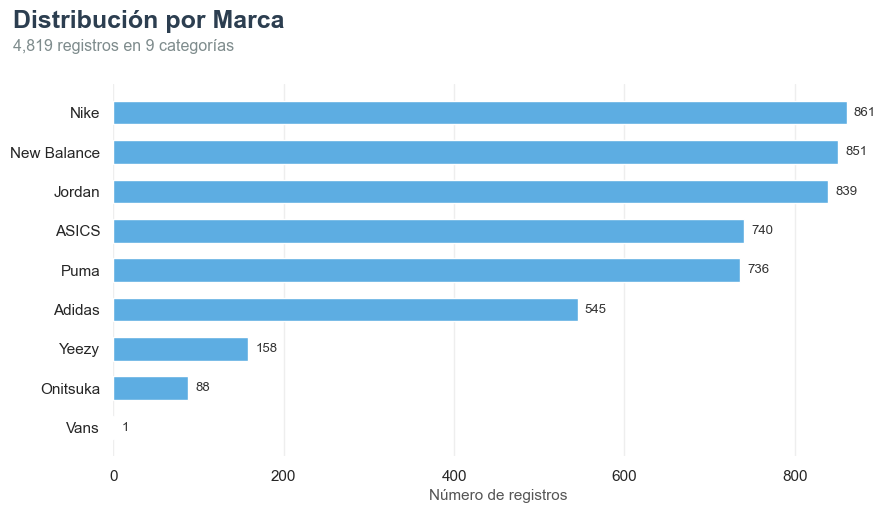

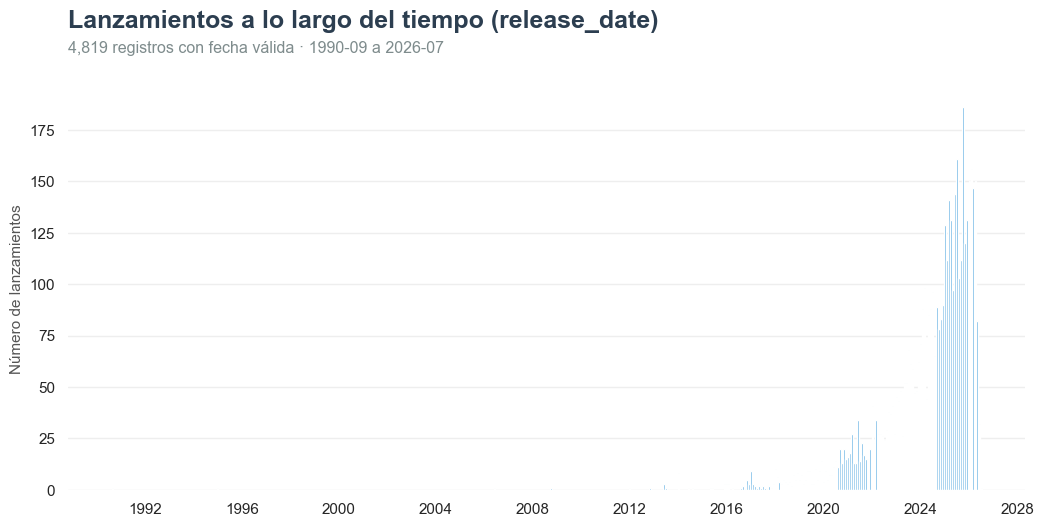

In [65]:
import matplotlib.ticker as mticker


# --- 1. CONFIGURACIÓN GLOBAL (Look Moderno / Editorial) ---
sns.set_theme(style="white", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#555555'

COLOR_PRINCIPAL = '#5dade2'
COLOR_SECUNDARIO = '#95a5a6'
COLOR_ACENTO = '#e67e22'
GRIS_TITULO = '#2c3e50'
GRIS_SUBTITULO = '#7f8c8d'
GRIS_SUBTITULO_AX = '#34495e'


# --- 2. FUNCIÓN: NUMÉRICA (Histograma + Boxplot apilados) ---
def plot_numeric(df, col, titulo=None, subtitulo=None, color=COLOR_PRINCIPAL,
                  bins=30, fmt_pct=False):
    """Distribución (KDE+hist) arriba y boxplot horizontal abajo, mismo eje x."""
    data = df[col].dropna()

    fig, (ax_hist, ax_box) = plt.subplots(
        2, 1, figsize=(10, 6.5), sharex=True,
        gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05}
    )

    titulo = titulo or f"Distribución de {col}"
    subtitulo = subtitulo or f"n = {len(data):,} registros · media = {data.mean():,.2f} · mediana = {data.median():,.2f}"
    fig.text(0.08, 0.96, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    # Histograma + KDE
    ax_hist.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)
    sns.histplot(data, bins=bins, kde=True, color=color, ax=ax_hist,
                 edgecolor='white', linewidth=0.5, alpha=0.85, zorder=2)
    ax_hist.axvline(data.mean(), color='#333333', linestyle='--', linewidth=1, zorder=3)
    ax_hist.set_ylabel("Frecuencia", fontsize=11, fontweight='medium')
    ax_hist.set_xlabel("")
    sns.despine(ax=ax_hist, left=True, bottom=True)

    # Boxplot horizontal
    sns.boxplot(x=data, ax=ax_box, color=color, width=0.5, linewidth=1.2,
                fliersize=3, showmeans=True,
                meanprops={"marker": "o", "markerfacecolor": "white",
                           "markeredgecolor": "#333333", "markersize": 5, "zorder": 3},
                zorder=2)
    ax_box.set_xlabel(col, fontsize=11, fontweight='medium')
    sns.despine(ax=ax_box, left=True, bottom=True)
    ax_box.set_yticks([])

    if fmt_pct:
        ax_box.xaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))

    plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.12)
    plt.show()


# --- 3. FUNCIÓN: CATEGÓRICA / BINARIA (Barras horizontales) ---
def plot_categorical(df, col, titulo=None, subtitulo=None, color=COLOR_PRINCIPAL,
                      top_n=None, orden_por='count'):
    """Conteo de categorías en barras horizontales, ordenadas."""
    conteo = df[col].value_counts(dropna=False)
    if orden_por == 'count':
        conteo = conteo.sort_values(ascending=True)
    if top_n:
        conteo = conteo.tail(top_n)

    fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(conteo) + 1.5)))

    titulo = titulo or f"Distribución de {col}"
    subtitulo = subtitulo or f"{conteo.sum():,} registros en {len(conteo)} categorías"
    fig.text(0.08, 0.96, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    ax.grid(axis='x', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)
    bars = ax.barh(conteo.index.astype(str), conteo.values, color=color, zorder=2, height=0.6)

    # Etiquetas de valor al final de cada barra
    for b in bars:
        w = b.get_width()
        ax.text(w + conteo.max() * 0.01, b.get_y() + b.get_height() / 2,
                f"{int(w):,}", va='center', fontsize=9.5, color='#333333')

    ax.set_xlabel("Número de registros", fontsize=11, fontweight='medium')
    ax.set_ylabel("")
    sns.despine(ax=ax, left=True, bottom=True)

    plt.subplots_adjust(top=0.85, left=0.18, right=0.95, bottom=0.12)
    plt.show()


# --- 4. FUNCIÓN: FECHA (Histograma temporal) ---
def plot_date(df, col, freq='M', titulo=None, subtitulo=None, color=COLOR_PRINCIPAL):
    """Conteo de registros agrupados por periodo (M=mes, Y=año, etc.)."""
    fechas = pd.to_datetime(df[col], errors='coerce').dropna()
    serie = fechas.dt.to_period(freq).value_counts().sort_index()
    serie.index = serie.index.to_timestamp()

    fig, ax = plt.subplots(figsize=(11, 5.5))

    titulo = titulo or f"Lanzamientos a lo largo del tiempo ({col})"
    subtitulo = subtitulo or f"{len(fechas):,} registros con fecha válida · {fechas.min():%Y-%m} a {fechas.max():%Y-%m}"
    fig.text(0.08, 0.96, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)
    ax.bar(serie.index, serie.values, width=20, color=color, zorder=2)
    ax.set_ylabel("Número de lanzamientos", fontsize=11, fontweight='medium')
    ax.set_xlabel("")
    sns.despine(ax=ax, left=True, bottom=True)

    plt.subplots_adjust(top=0.85, left=0.08, right=0.95, bottom=0.12)
    plt.show()


# ============================================================
# 5. EJECUCIÓN: recorrer todas las variables del dataset
# ============================================================
if __name__ == "__main__":

    # --- Variables numéricas continuas ---
    variables_numericas = {
        'retail_price':              dict(titulo="Precio de Retail (USD)"),
        'highest_value':              dict(titulo="Valor Máximo Histórico (USD)"),
        'pre_release_peak':           dict(titulo="Pico de Precio Pre-Lanzamiento (USD)"),
        'current_value':              dict(titulo="Valor Actual (USD)"),
        'lowest_value_post_release':  dict(titulo="Valor Mínimo Post-Lanzamiento (USD)"),
        'roi_pct':                    dict(titulo="ROI (%)", fmt_pct=True, color=COLOR_ACENTO),
        'pre_release_premium_pct':    dict(titulo="Premium Pre-Lanzamiento (%)", fmt_pct=True, color=COLOR_ACENTO),
        'hype_decay_pct':              dict(titulo="Caída del Hype (%)", fmt_pct=True, color=COLOR_ACENTO),
        'days_to_peak':                dict(titulo="Días hasta el Pico de Precio", color=COLOR_SECUNDARIO),
        'price_volatility':            dict(titulo="Volatilidad del Precio", color=COLOR_SECUNDARIO),
    }

    for col, params in variables_numericas.items():
        if col in df.columns:
            plot_numeric(df, col, **params)

    # --- Variable binaria ---
    if 'is_above_retail' in df.columns:
        plot_categorical(df, 'is_above_retail',
                          titulo="¿Está por Encima del Retail?",
                          subtitulo="Comparación de registros sobre vs. bajo precio original",
                          color=COLOR_PRINCIPAL)

    # --- Variable categórica con muchas categorías ---
    if 'brand' in df.columns:
        plot_categorical(df, 'brand',
                          titulo="Distribución por Marca",
                          top_n=15,  # top 15 marcas más frecuentes
                          color=COLOR_PRINCIPAL)

    # --- Variable de fecha ---
    if 'release_date' in df.columns:
        plot_date(df, 'release_date', freq='M', color=COLOR_PRINCIPAL)

# bivariate EDA

In [66]:
sns.set_theme(style="white", context="notebook")
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['text.color'] = '#333333'
plt.rcParams['axes.labelcolor'] = '#555555'

COLOR_PRINCIPAL = '#5dade2'
COLOR_SECUNDARIO = '#95a5a6'
COLOR_ACENTO = '#e67e22'
GRIS_TITULO = '#2c3e50'
GRIS_SUBTITULO = '#7f8c8d'
CMAP_CORR = 'RdBu_r'

In [ ]:
def plot_bar_mean_by_brand(df, num_col='highest_value', cat_col='brand', titulo=None, subtitulo=None,
                           paleta=None, top_n=15, orden=None, fmt_pct=False):
    # 1. Limpieza y agrupación por promedio
    sub = df[[num_col, cat_col]].dropna()

    # Calcular las medias por categoría
    df_means = sub.groupby(cat_col)[num_col].mean().reset_index()

    # 2. Filtrar Top N si corresponde (por volumen de registros o por mayor media,
    # en este caso filtramos por las marcas más frecuentes para que sea representativo)
    if top_n:
        top_cats = sub[cat_col].value_counts().head(top_n).index
        df_means = df_means[df_means[cat_col].isin(top_cats)]

    # 3. Ordenar (por defecto de mayor a menor promedio)
    if orden is None:
        df_means = df_means.sort_values(by=num_col, ascending=False)
        orden = df_means[cat_col].tolist()
    else:
        df_means = df_means.set_index(cat_col).loc[orden].reset_index()

    # 4. Configuración del lienzo (Tamaño dinámico según cantidad de marcas)
    fig, ax = plt.subplots(figsize=(max(10, 0.6 * len(orden) + 3), 6.5))

    # Títulos con el mismo estilo editorial
    titulo = titulo or f"Promedio de {num_col} por {cat_col.capitalize()}"
    subtitulo = subtitulo or f"Basado en el top {len(orden)} de marcas con más registros"
    fig.text(0.08, 0.96, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    # Rejilla de fondo
    ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

    # 5. Gráfico de barras aplicando la corrección de Seaborn (hue + legend=False)
    sns.barplot(
        data=df_means, x=cat_col, y=num_col, order=orden, hue=cat_col,
        palette=paleta, width=0.6, linewidth=0, ax=ax, zorder=2, legend=False
    )

    # Estilizado de ejes
    ax.set_xlabel(cat_col.capitalize(), fontsize=11, fontweight='medium')
    ax.set_ylabel(f"Media de {num_col}", fontsize=11, fontweight='medium')

    if fmt_pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))

    # Rotación de etiquetas si hay muchas marcas
    plt.xticks(rotation=30 if len(orden) > 4 else 0, ha='right' if len(orden) > 4 else 'center')

    # Despine de alta calidad
    sns.despine(ax=ax, left=True, bottom=True)

    plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.2)
    plt.show()

In [68]:
# %%
def plot_scatter(df, x, y, hue=None, titulo=None, subtitulo=None,
                  color=COLOR_PRINCIPAL, paleta_hue=None, alpha=0.5):
    sub = df[[x, y] + ([hue] if hue else [])].dropna()
    corr = sub[x].corr(sub[y])

    fig, ax = plt.subplots(figsize=(10, 6.5))

    titulo = titulo or f"{y} vs. {x}"
    subtitulo = subtitulo or f"n = {len(sub):,} · correlación de Pearson = {corr:.2f}"
    fig.text(0.08, 0.96, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    ax.grid(color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

    if hue:
        sns.scatterplot(data=sub, x=x, y=y, hue=hue, ax=ax, alpha=alpha,
                         s=25, palette=paleta_hue, zorder=2, edgecolor='none')
        ax.legend(frameon=False, title=hue, loc='best')
    else:
        ax.scatter(sub[x], sub[y], color=color, alpha=alpha, s=25,
                   edgecolor='none', zorder=2)

    sns.regplot(data=sub, x=x, y=y, scatter=False, ax=ax,
                color='#333333', line_kws={'linewidth': 1.5, 'linestyle': '--'})

    ax.set_xlabel(x, fontsize=11, fontweight='medium')
    ax.set_ylabel(y, fontsize=11, fontweight='medium')
    sns.despine(ax=ax, left=True, bottom=True)

    plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.12)
    plt.show()

In [69]:
def plot_box_by_category(df, num_col, cat_col, titulo=None, subtitulo=None,
                         paleta=None, top_n=None, orden=None, fmt_pct=False):
    sub = df[[num_col, cat_col]].dropna()

    if top_n:
        top_cats = sub[cat_col].value_counts().head(top_n).index
        sub = sub[sub[cat_col].isin(top_cats)]

    if orden is None:
        orden = sub.groupby(cat_col)[num_col].median().sort_values(ascending=False).index

    fig, ax = plt.subplots(figsize=(max(10, 0.55 * len(orden) + 4), 6.5))

    titulo = titulo or f"{num_col} según {cat_col}"
    subtitulo = subtitulo or f"n = {len(sub):,} registros · {sub[cat_col].nunique()} categorías"
    fig.text(0.08, 0.96, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

    # SE CORRIGE AGREGANDO: hue=cat_col y legend=False
    sns.boxplot(
        data=sub, x=cat_col, y=num_col, hue=cat_col, order=orden, ax=ax,
        palette=paleta, width=0.5, linewidth=1.2, fliersize=3,
        showmeans=True,
        meanprops={"marker": "o", "markerfacecolor": "white",
                   "markeredgecolor": "#333333", "markersize": 5, "zorder": 3},
        zorder=2,
        legend=False
    )

    ax.set_xlabel(cat_col, fontsize=11, fontweight='medium')
    ax.set_ylabel(num_col, fontsize=11, fontweight='medium')
    if fmt_pct:
        ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=100))
    plt.xticks(rotation=30 if len(orden) > 4 else 0, ha='right' if len(orden) > 4 else 'center')
    sns.despine(ax=ax, left=True, bottom=True)

    plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.2)
    plt.show()

In [70]:
# %%
def plot_correlation_heatmap(df, cols, titulo="Matriz de Correlaciones",
                              subtitulo="Coeficiente de Pearson entre variables numéricas"):
    corr = df[cols].corr()

    fig, ax = plt.subplots(figsize=(10, 8.5))
    fig.text(0.08, 0.97, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.935, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    mask = np.triu(np.ones_like(corr, dtype=bool), k=1)
    sns.heatmap(corr, mask=mask, cmap=CMAP_CORR, center=0, vmin=-1, vmax=1,
                annot=True, fmt=".2f", linewidths=1, linecolor='white',
                cbar_kws={'shrink': 0.8, 'label': 'Correlación'}, ax=ax,
                annot_kws={'fontsize': 9})

    ax.set_xticklabels(ax.get_xticklabels(), rotation=35, ha='right')
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)
    ax.tick_params(left=False, bottom=False)

    plt.subplots_adjust(top=0.88, left=0.18, right=0.98, bottom=0.2)
    plt.show()

In [71]:
# %%
def plot_stacked_proportion(df, cat_col, bin_col, top_n=12,
                             titulo=None, subtitulo=None,
                             colores=(COLOR_SECUNDARIO, COLOR_PRINCIPAL)):
    sub = df[[cat_col, bin_col]].dropna()
    top_cats = sub[cat_col].value_counts().head(top_n).index
    sub = sub[sub[cat_col].isin(top_cats)]

    tabla = pd.crosstab(sub[cat_col], sub[bin_col], normalize='index') * 100
    tabla = tabla.loc[tabla.iloc[:, -1].sort_values(ascending=True).index]

    fig, ax = plt.subplots(figsize=(10, max(4, 0.4 * len(tabla) + 1.5)))

    titulo = titulo or f"{bin_col} según {cat_col}"
    subtitulo = subtitulo or f"Top {len(tabla)} categorías por frecuencia · proporción (%) horizontal"
    fig.text(0.08, 0.96, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    ax.grid(axis='x', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)
    izquierda = np.zeros(len(tabla))
    for i, col in enumerate(tabla.columns):
        ax.barh(tabla.index.astype(str), tabla[col], left=izquierda,
                color=colores[i % len(colores)], label=str(col), zorder=2, height=0.6)
        izquierda += tabla[col].values

    ax.set_xlabel("Proporción (%)", fontsize=11, fontweight='medium')
    ax.set_ylabel("")
    ax.legend(frameon=False, title=bin_col, bbox_to_anchor=(1.02, 1), loc='upper left')
    sns.despine(ax=ax, left=True, bottom=True)

    plt.subplots_adjust(top=0.85, left=0.18, right=0.82, bottom=0.12)
    plt.show()

In [72]:
# %%
def plot_trend_over_time(df, date_col, value_col, freq='Y',
                          titulo=None, subtitulo=None, color=COLOR_PRINCIPAL):
    sub = df[[date_col, value_col]].copy()
    sub[date_col] = pd.to_datetime(sub[date_col], errors='coerce')
    sub = sub.dropna()
    serie = sub.set_index(date_col)[value_col].resample(freq).mean()

    fig, ax = plt.subplots(figsize=(11, 5.5))

    titulo = titulo or f"Evolución de {value_col} por año de lanzamiento"
    subtitulo = subtitulo or f"Promedio anual · {sub[date_col].dt.year.min()}–{sub[date_col].dt.year.max()}"
    fig.text(0.08, 0.96, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)
    ax.plot(serie.index, serie.values, color=color, linewidth=2, marker='o',
            markersize=4, zorder=2)
    ax.fill_between(serie.index, serie.values, serie.values.min(), color=color, alpha=0.08, zorder=1)

    ax.set_ylabel(value_col, fontsize=11, fontweight='medium')
    ax.set_xlabel("")
    sns.despine(ax=ax, left=True, bottom=True)

    plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.12)
    plt.show()

## Correlations

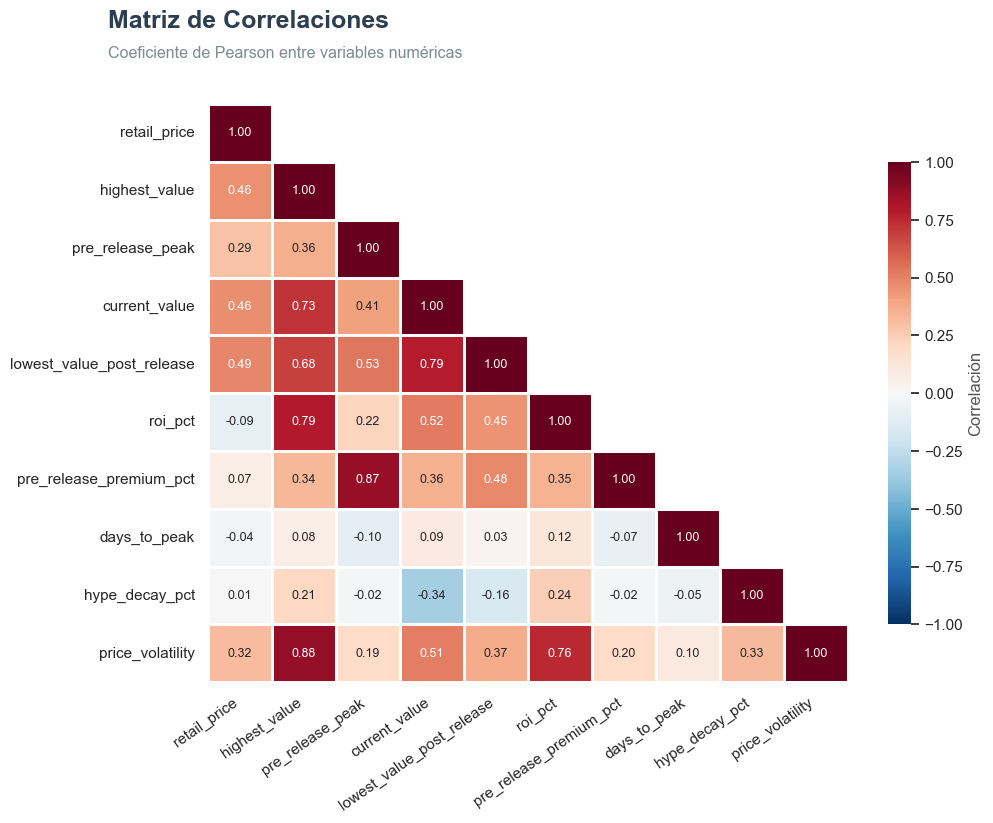

In [73]:
# %%
numericas = ['retail_price', 'highest_value', 'pre_release_peak', 'current_value',
             'lowest_value_post_release', 'roi_pct', 'pre_release_premium_pct',
             'days_to_peak', 'hype_decay_pct', 'price_volatility']
plot_correlation_heatmap(df, [c for c in numericas if c in df.columns])

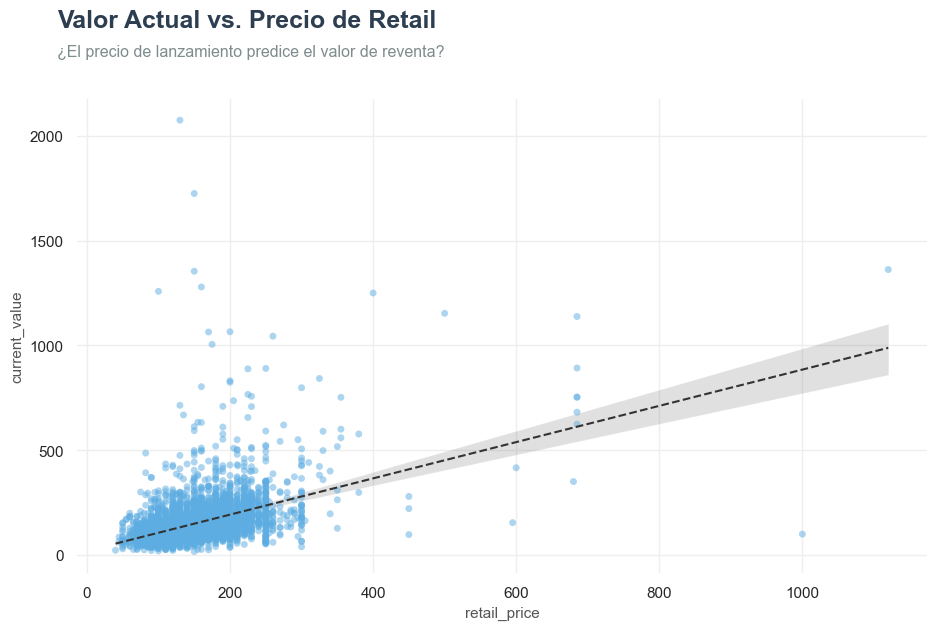

In [74]:
# %%
plot_scatter(df, 'retail_price', 'current_value',
             titulo="Valor Actual vs. Precio de Retail",
             subtitulo="¿El precio de lanzamiento predice el valor de reventa?")

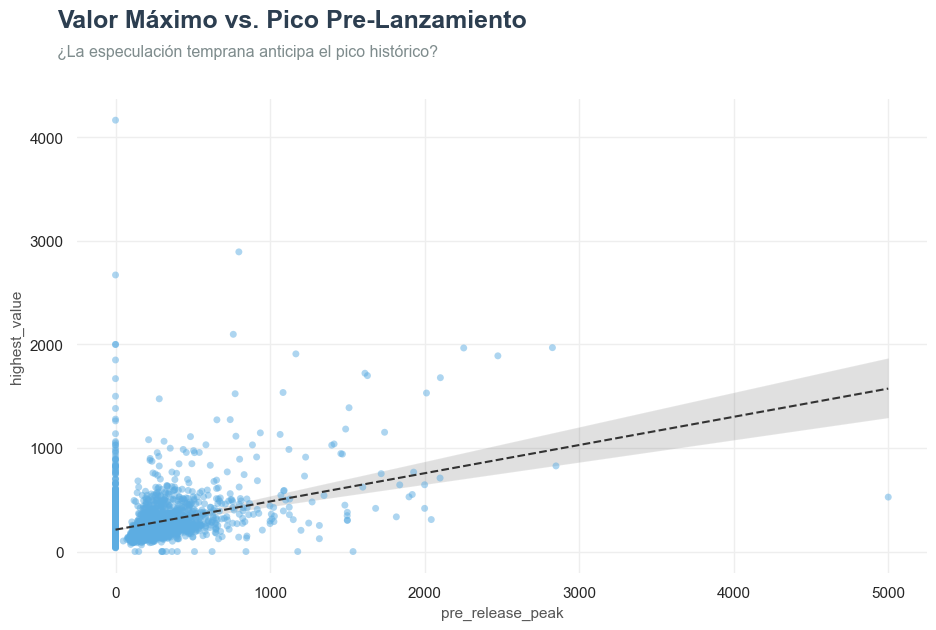

In [75]:
# %%
plot_scatter(df, 'pre_release_peak', 'highest_value',
             titulo="Valor Máximo vs. Pico Pre-Lanzamiento",
             subtitulo="¿La especulación temprana anticipa el pico histórico?")

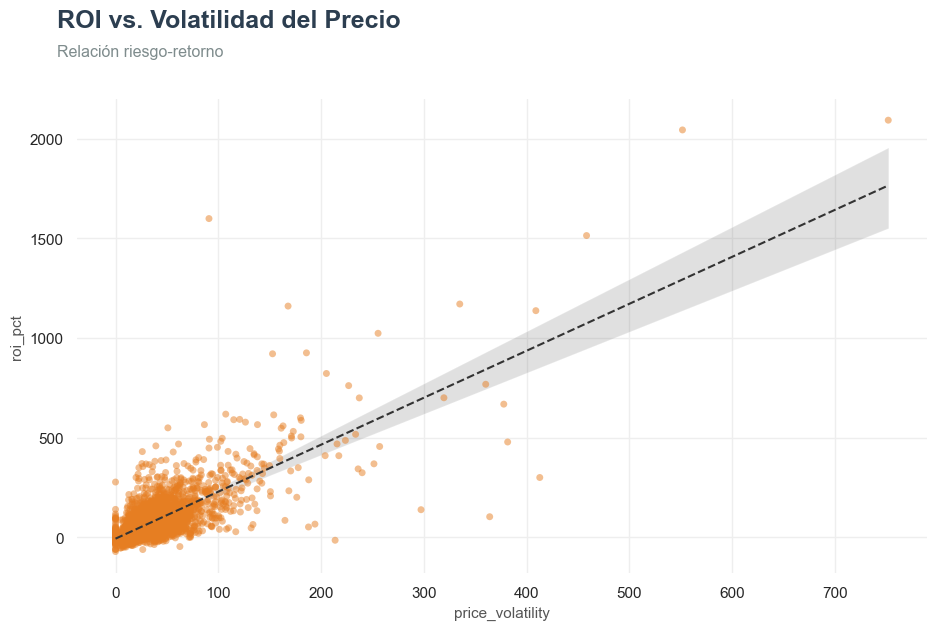

In [76]:
# %%
plot_scatter(df, 'price_volatility', 'roi_pct',
             titulo="ROI vs. Volatilidad del Precio",
             subtitulo="Relación riesgo-retorno", color=COLOR_ACENTO)

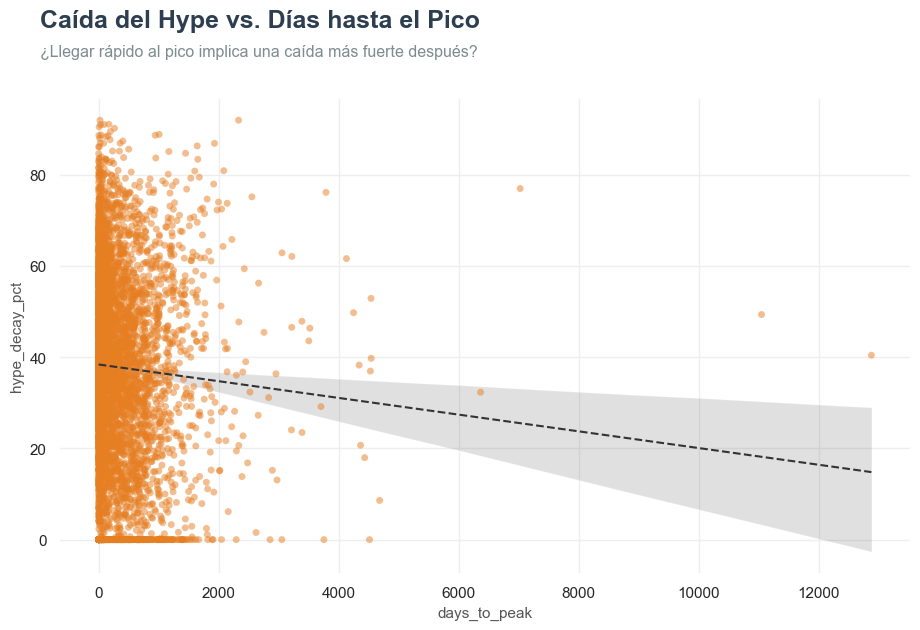

In [77]:
# %%
plot_scatter(df, 'days_to_peak', 'hype_decay_pct',
             titulo="Caída del Hype vs. Días hasta el Pico",
             subtitulo="¿Llegar rápido al pico implica una caída más fuerte después?",
             color=COLOR_ACENTO)

## Roi vs is_above_retail

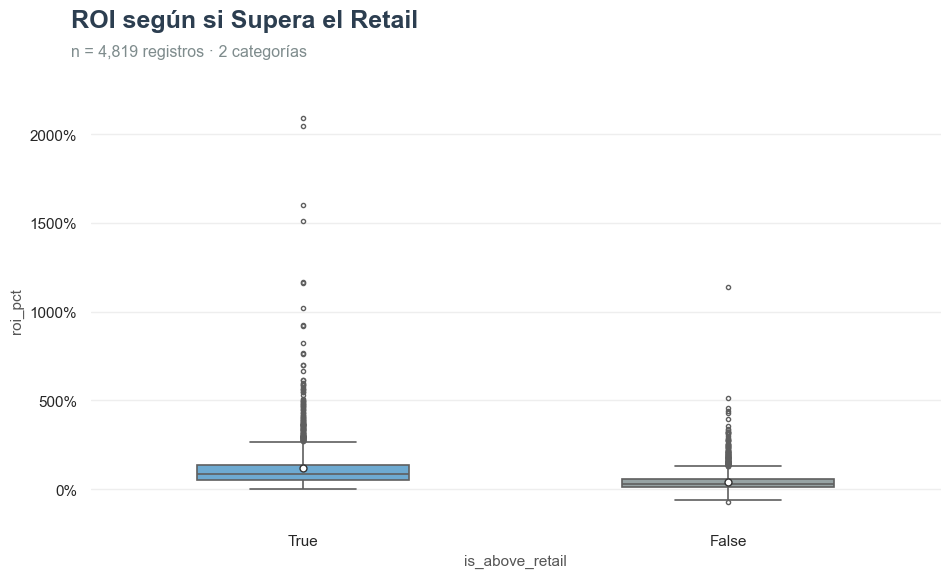

In [78]:
# %%
plot_box_by_category(df, 'roi_pct', 'is_above_retail',
                      titulo="ROI según si Supera el Retail",
                      paleta={0: COLOR_SECUNDARIO, 1: COLOR_PRINCIPAL,
                              False: COLOR_SECUNDARIO, True: COLOR_PRINCIPAL},
                      fmt_pct=True)

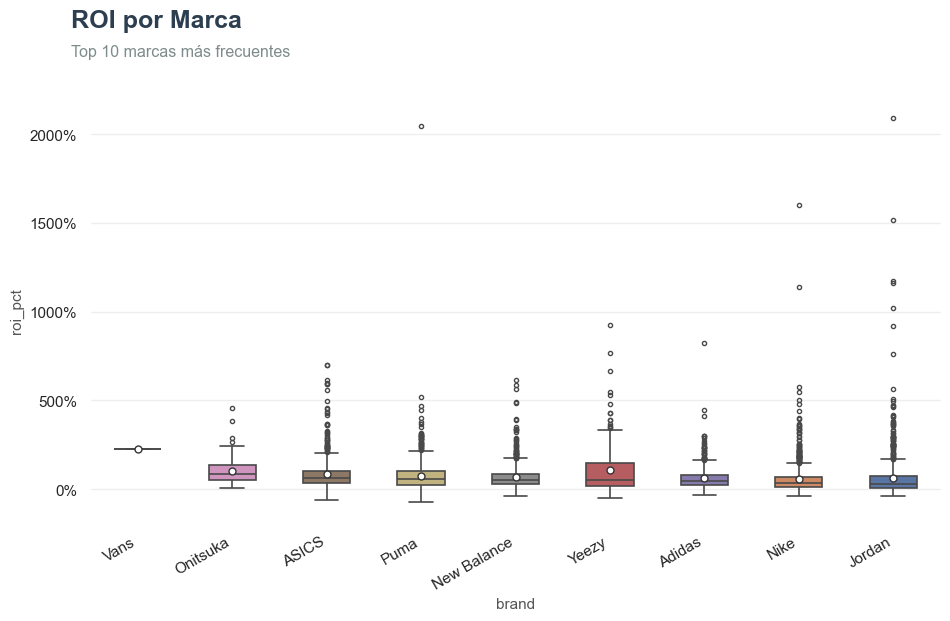

In [79]:
# %%
plot_box_by_category(df, 'roi_pct', 'brand', top_n=10,
                      titulo="ROI por Marca", subtitulo="Top 10 marcas más frecuentes",
                      fmt_pct=True)

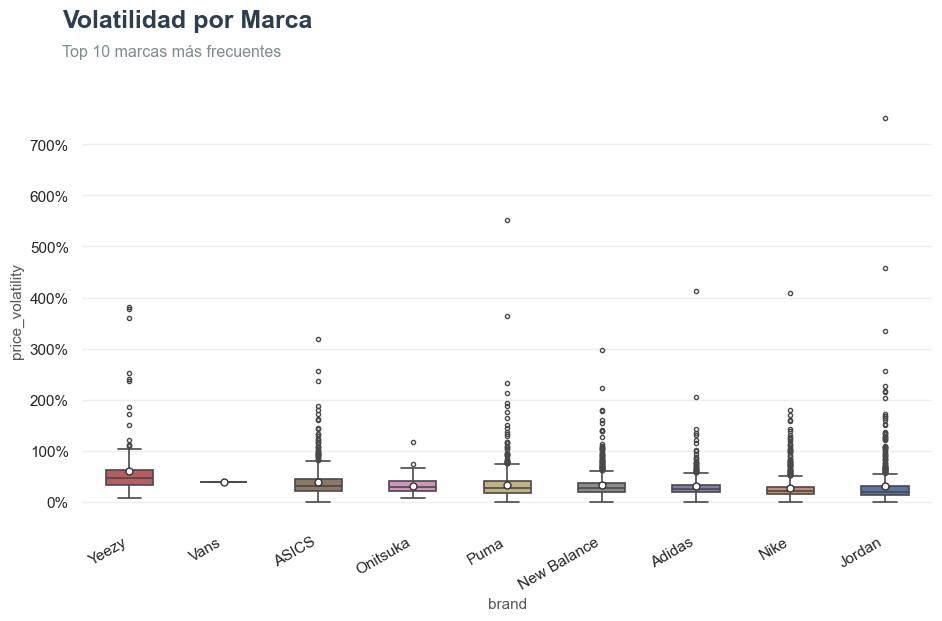

In [80]:
plot_box_by_category(df, 'price_volatility', 'brand', top_n=10,
                      titulo="Volatilidad por Marca", subtitulo="Top 10 marcas más frecuentes",
                      fmt_pct=True)

D:\Temp\ipykernel_6872\833416046.py:35: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


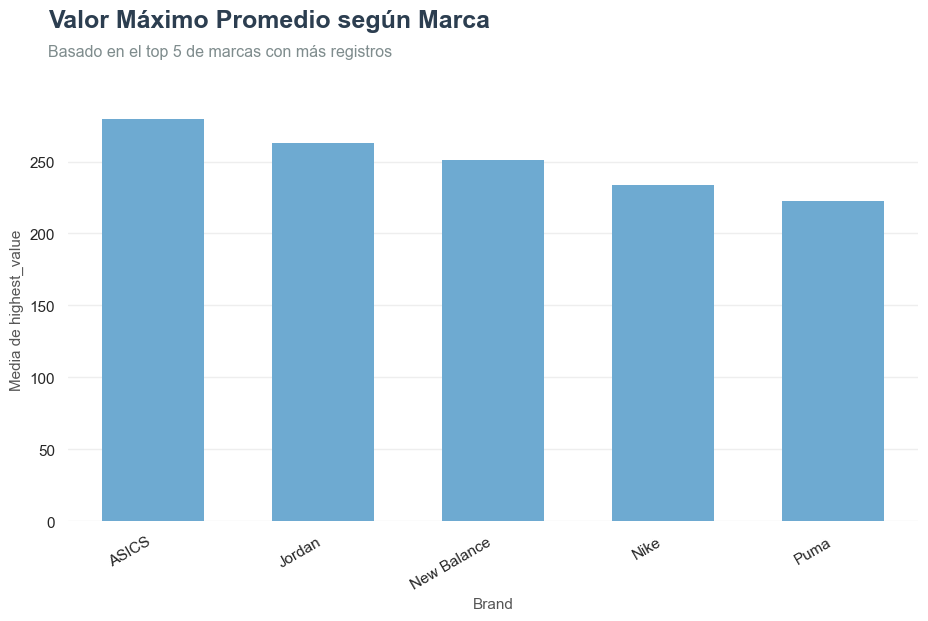

In [81]:
plot_bar_mean_by_brand(
    df,
    num_col='highest_value',
    cat_col='brand',
    titulo="Valor Máximo Promedio según Marca",
    paleta=[COLOR_PRINCIPAL],
    top_n=5
)

D:\Temp\ipykernel_6872\833416046.py:35: UserWarning: 
The palette list has fewer values (1) than needed (5) and will cycle, which may produce an uninterpretable plot.
  sns.barplot(


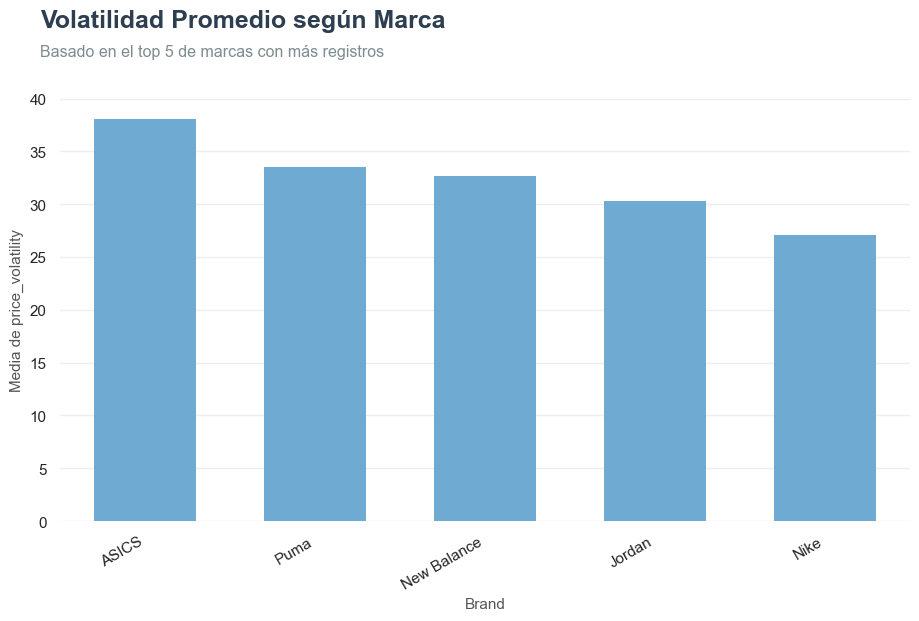

In [82]:
plot_bar_mean_by_brand(
    df,
    num_col='price_volatility',
    cat_col='brand',
    titulo="Volatilidad Promedio según Marca",
    paleta=[COLOR_PRINCIPAL],
    top_n=5
)

D:\Temp\ipykernel_6872\3269592481.py:7: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  serie = sub.set_index(date_col)[value_col].resample(freq).mean()


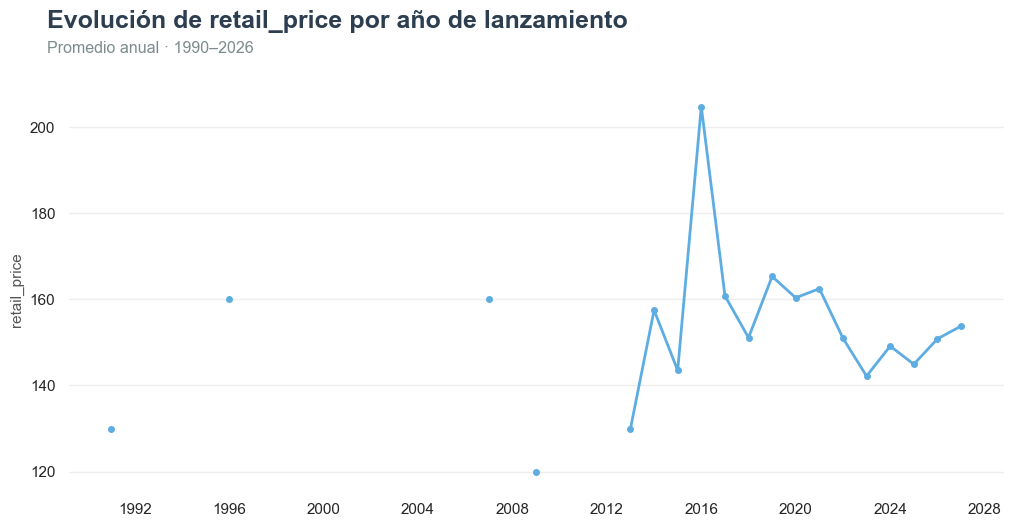

In [83]:
# %%
plot_trend_over_time(df, 'release_date', 'retail_price', freq='Y')

D:\Temp\ipykernel_6872\3269592481.py:7: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  serie = sub.set_index(date_col)[value_col].resample(freq).mean()


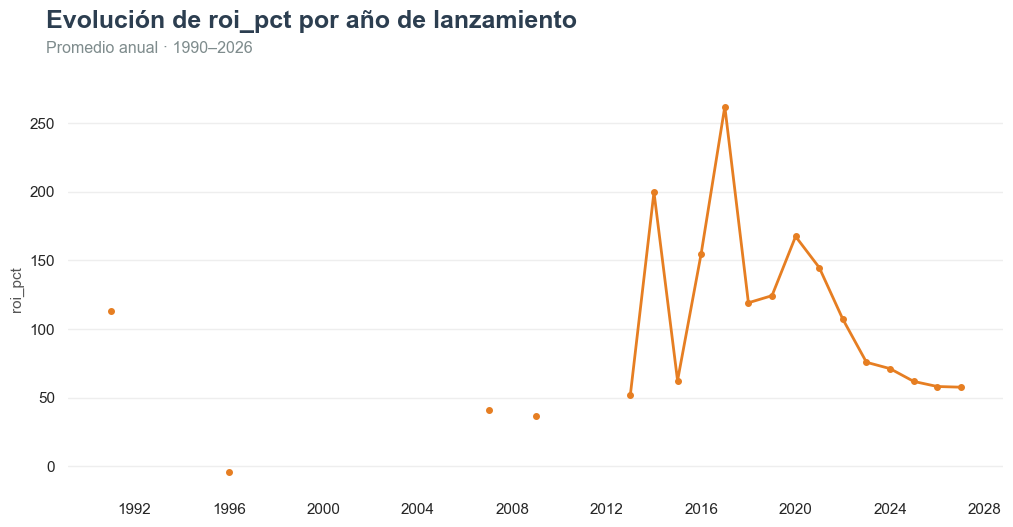

In [84]:
# %%
plot_trend_over_time(df, 'release_date', 'roi_pct', freq='Y', color=COLOR_ACENTO)

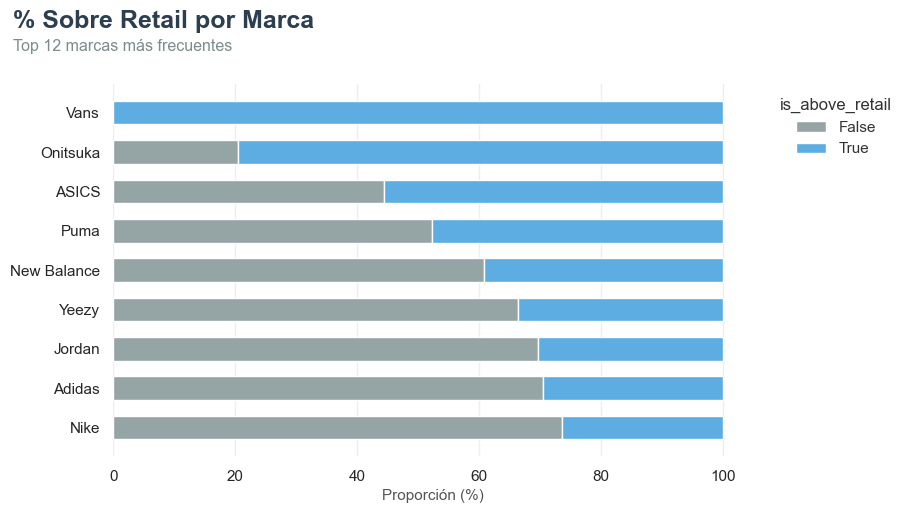

In [85]:
# %%
plot_stacked_proportion(df, 'brand', 'is_above_retail', top_n=12,
                         titulo="% Sobre Retail por Marca",
                         subtitulo="Top 12 marcas más frecuentes")

## why is the retail so high in 2016?

In [86]:
df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')
conteo_anual = df['release_date'].dt.year.value_counts().sort_index()
print(conteo_anual)

release_date
1990       1
1995       1
2006       1
2008       1
2012       2
2013       4
2014      10
2015       5
2016      18
2017      27
2018      61
2019      82
2020     136
2021     225
2022     374
2023     611
2024     975
2025    1567
2026     718
Name: count, dtype: int64


In [87]:
df_2016 = df[df['release_date'].dt.year == 2016]
print(f"Registros en 2016: {len(df_2016)}")
df_2016['retail_price'].describe()

Registros en 2016: 18


count     18.000000
mean     160.833333
std       49.977936
min       65.000000
25%      136.250000
50%      170.000000
75%      197.500000
max      220.000000
Name: retail_price, dtype: float64

In [88]:
# %%
cols_revisar = ['brand', 'retail_price', 'highest_value', 'current_value', 'release_date']
df_2016[cols_revisar].sort_values('retail_price', ascending=False)

,brand,retail_price,highest_value,current_value,release_date
155,Yeezy,220.0,1272,244.0,2016-11-23
156,Yeezy,220.0,975,278.0,2016-12-17
897,Jordan,220.0,481,318.0,2016-12-10
1293,Jordan,220.0,629,215.0,2016-02-13
591,Yeezy,200.0,1536,261.0,2016-02-19
1523,Jordan,190.0,319,174.0,2016-08-20
3800,Nike,190.0,234,95.0,2016-11-06
2406,ASICS,170.0,280,158.0,2016-01-01
3696,Nike,170.0,260,147.0,2016-11-19
1758,ASICS,170.0,288,204.0,2016-01-01


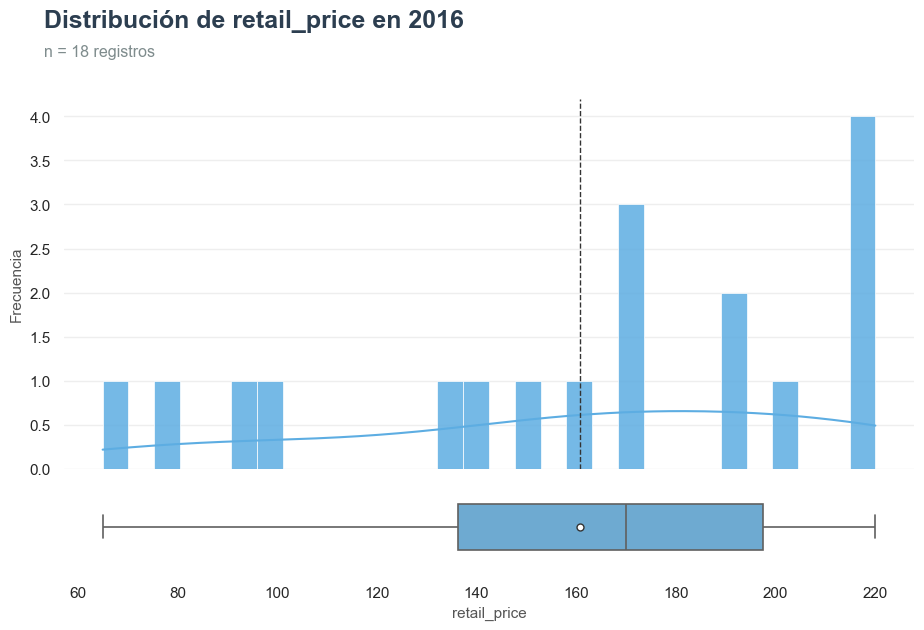

In [89]:
# %%
plot_numeric(df_2016, 'retail_price',
             titulo="Distribución de retail_price en 2016",
             subtitulo=f"n = {len(df_2016)} registros")

In [90]:
# %%
df_2016.groupby('brand')['retail_price'].agg(['count', 'mean', 'max']).sort_values('mean', ascending=False)

,count,mean,max
brand,,,
Yeezy,3,213.333333,220.0
Jordan,4,197.500000,220.0
ASICS,2,170.000000,170.0
Nike,5,146.000000,190.0
Puma,4,98.750000,150.0


In [91]:
# %%
df_2015 = df[df['release_date'].dt.year == 2015]
print(f"Registros en 2015: {len(df_2015)}")
df_2015[['brand', 'retail_price', 'highest_value', 'current_value', 'release_date']].sort_values('retail_price', ascending=False)

Registros en 2015: 5


,brand,retail_price,highest_value,current_value,release_date
2299,ASICS,325.0,1262,381.0,2015-12-23
4532,Puma,189.0,523,145.0,2015-12-12
4564,Puma,185.0,280,100.0,2015-12-12
1594,Jordan,165.0,343,130.0,2015-06-10
4107,Nike,160.0,400,105.0,2015-05-05


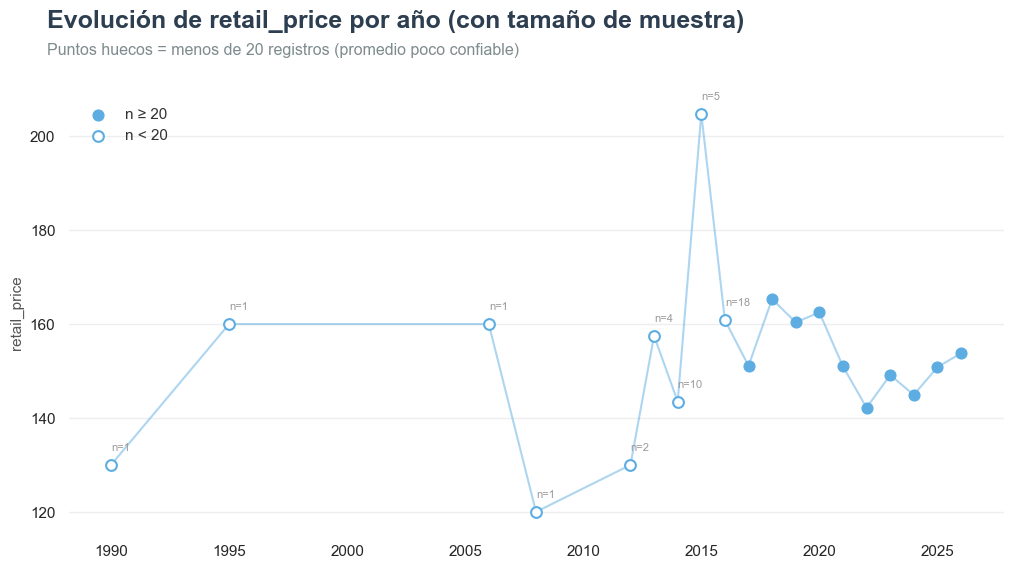

In [92]:
# %%
def plot_trend_with_n(df, date_col, value_col, min_n=10, color=COLOR_PRINCIPAL):
    sub = df[[date_col, value_col]].copy()
    sub[date_col] = pd.to_datetime(sub[date_col], errors='coerce')
    sub = sub.dropna()
    sub['anio'] = sub[date_col].dt.year

    agg = sub.groupby('anio')[value_col].agg(['mean', 'count'])
    confiable = agg[agg['count'] >= min_n]
    poco_confiable = agg[agg['count'] < min_n]

    fig, ax = plt.subplots(figsize=(11, 6))

    fig.text(0.08, 0.96, f"Evolución de {value_col} por año (con tamaño de muestra)",
              fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, f"Puntos huecos = menos de {min_n} registros (promedio poco confiable)",
              fontsize=11.5, color=GRIS_SUBTITULO)

    ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)
    ax.plot(agg.index, agg['mean'], color=color, linewidth=1.5, zorder=2, alpha=0.5)

    ax.scatter(confiable.index, confiable['mean'], color=color, s=60, zorder=3, label=f'n ≥ {min_n}')
    ax.scatter(poco_confiable.index, poco_confiable['mean'], facecolors='white',
               edgecolors=color, linewidths=1.5, s=60, zorder=3, label=f'n < {min_n}')

    for anio, row in poco_confiable.iterrows():
        ax.annotate(f"n={int(row['count'])}", (anio, row['mean']),
                    textcoords="offset points", xytext=(0, 10), fontsize=8, color='#999999')

    ax.set_ylabel(value_col, fontsize=11, fontweight='medium')
    ax.legend(frameon=False, loc='upper left')
    sns.despine(ax=ax, left=True, bottom=True)
    plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.12)
    plt.show()

plot_trend_with_n(df, 'release_date', 'retail_price', min_n=20)

In [93]:
# %%
df['anio'] = df['release_date'].dt.year

metricas_hype = ['roi_pct', 'pre_release_premium_pct', 'hype_decay_pct']
resumen = df.groupby('anio')[metricas_hype].agg(['mean', 'count'])
print(resumen)

         roi_pct       pre_release_premium_pct       hype_decay_pct      
            mean count                    mean count           mean count
anio                                                                     
1990  113.076923     1                0.000000     1      40.433213     1
1995   -3.750000     1                0.000000     1      49.350649     1
2006   41.250000     1                0.000000     1      76.991150     1
2008   36.666667     1                0.000000     1      32.317073     1
2012   52.202381     2                0.000000     2      37.178808     2
2013  199.705175     4               17.187500     4      47.018498     4
2014   62.503782    10                0.000000    10      33.532344    10
2015  154.851482     5                0.000000     5      68.444000     5
2016  262.040946    18               57.748837    18      52.980351    18
2017  119.161941    27               36.952862    27      51.074616    27
2018  124.340909    61               2

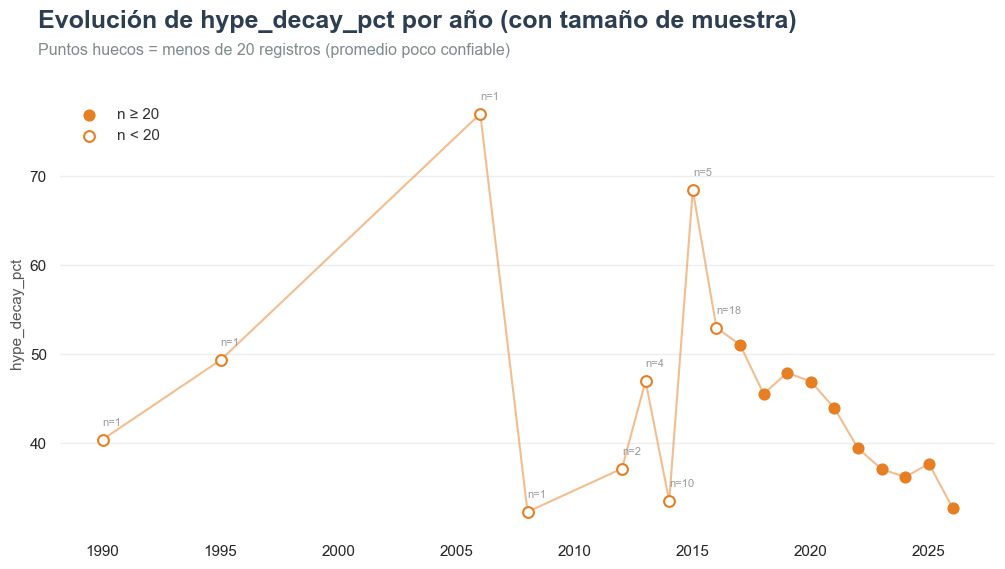

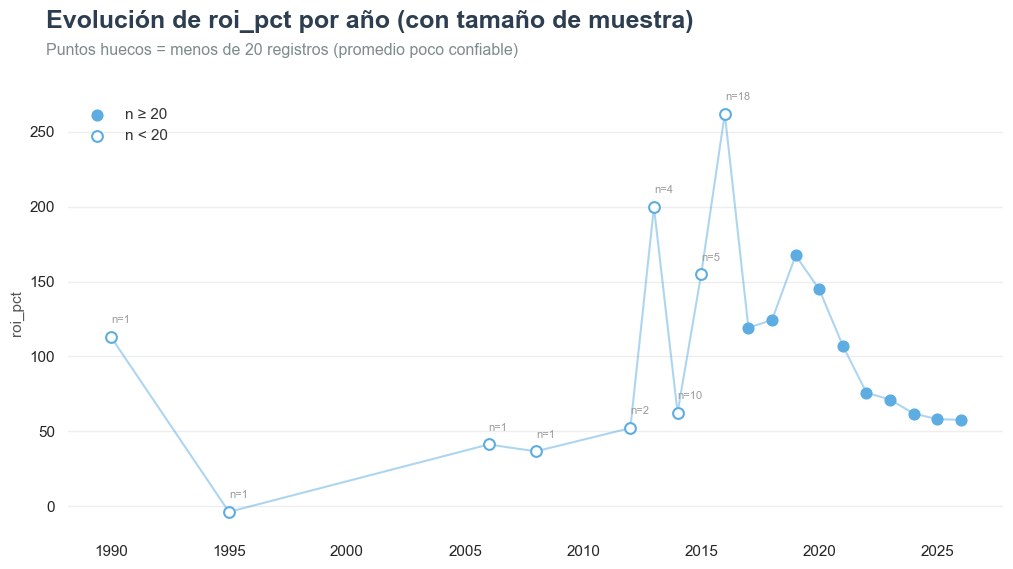

In [94]:
# %%
plot_trend_with_n(df, 'release_date', 'hype_decay_pct', min_n=20, color=COLOR_ACENTO)
plot_trend_with_n(df, 'release_date', 'roi_pct', min_n=20)

In [95]:
hoy = pd.Timestamp.now().normalize()

df['days_since_release'] = (hoy - df['release_date']).dt.days

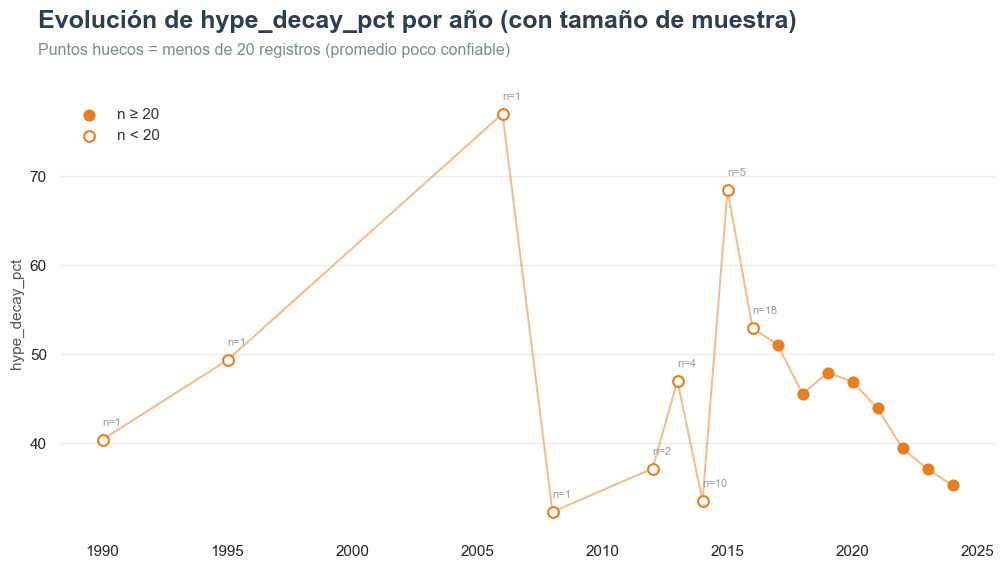

In [96]:
# %%
df_maduros = df[df['days_since_release'] >= 730]  # al menos 2 años
plot_trend_with_n(df_maduros, 'release_date', 'hype_decay_pct', min_n=20, color=COLOR_ACENTO)

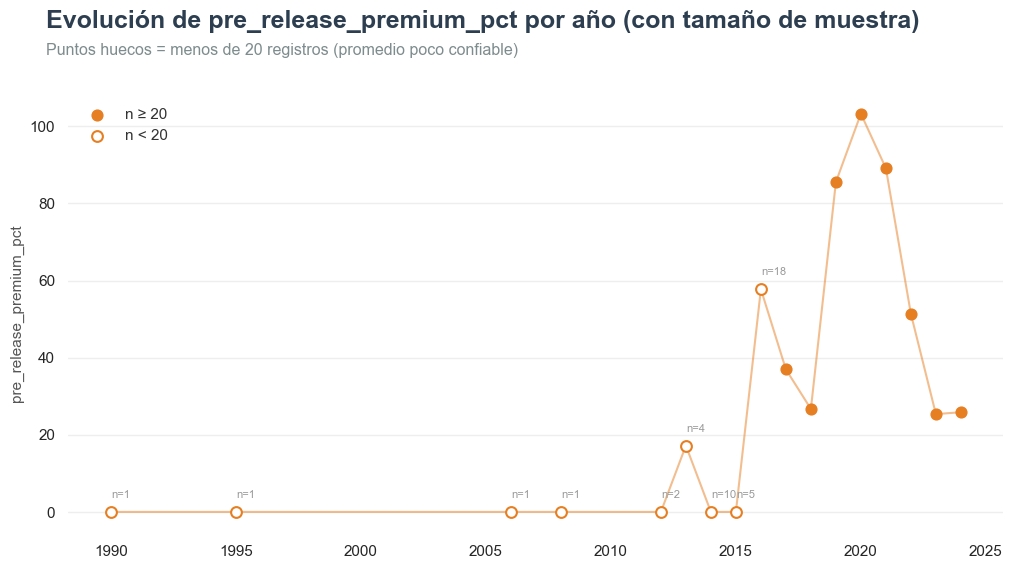

In [97]:
# %%
plot_trend_with_n(df_maduros, 'release_date', 'pre_release_premium_pct', min_n=20, color=COLOR_ACENTO)

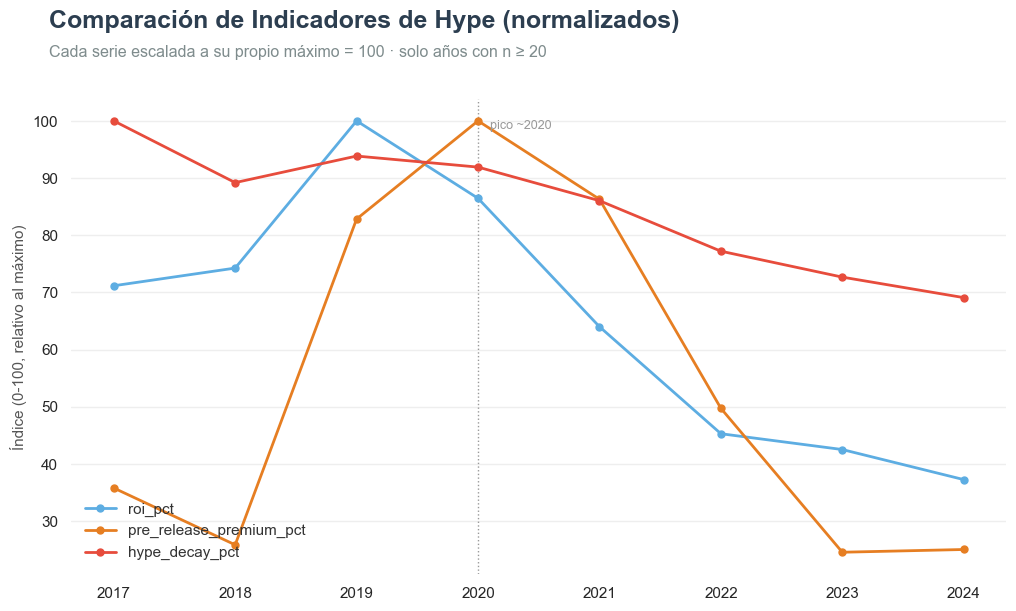

In [98]:
# %%
def plot_comparacion_normalizada(df, date_col, metricas, colores, min_n=20):
    sub = df.copy()
    sub['anio'] = sub[date_col].dt.year

    fig, ax = plt.subplots(figsize=(11, 6.5))
    fig.text(0.08, 0.96, "Comparación de Indicadores de Hype (normalizados)",
              fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, "Cada serie escalada a su propio máximo = 100 · solo años con n ≥ " + str(min_n),
              fontsize=11.5, color=GRIS_SUBTITULO)
    ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

    for metrica, color in zip(metricas, colores):
        agg = sub.groupby('anio')[metrica].agg(['mean', 'count'])
        agg = agg[agg['count'] >= min_n]
        normalizado = agg['mean'] / agg['mean'].max() * 100
        ax.plot(agg.index, normalizado, color=color, linewidth=2, marker='o',
                markersize=5, label=metrica, zorder=2)

    ax.axvline(2020, color='#999999', linestyle=':', linewidth=1, zorder=1)
    ax.text(2020.1, ax.get_ylim()[1]*0.95, 'pico ~2020', fontsize=9, color='#999999')

    ax.set_ylabel("Índice (0-100, relativo al máximo)", fontsize=11, fontweight='medium')
    ax.legend(frameon=False, loc='lower left')
    sns.despine(ax=ax, left=True, bottom=True)
    plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.12)
    plt.show()

plot_comparacion_normalizada(
    df_maduros, 'release_date',
    metricas=['roi_pct', 'pre_release_premium_pct', 'hype_decay_pct'],
    colores=[COLOR_PRINCIPAL, COLOR_ACENTO, COLOR_ALERTA]
)

In [99]:
# %%
hoy = pd.Timestamp.now().normalize()
df['days_since_release'] = (hoy - df['release_date']).dt.days
df['anio'] = df['release_date'].dt.year

In [100]:
# %%
ventana = df[(df['days_since_release'] >= 730) & (df['days_since_release'] <= 800)]
print(f"Registros en la ventana: {len(ventana)}")
print(ventana['release_date'].agg(['min', 'max']))
print(ventana['anio'].value_counts())

Registros en la ventana: 175
min   2024-04-10
max   2024-06-19
Name: release_date, dtype: datetime64[ns]
anio
2024    175
Name: count, dtype: int64


In [101]:
# %%
metricas_hype = ['roi_pct', 'pre_release_premium_pct', 'hype_decay_pct']
df_modelo = df.dropna(subset=metricas_hype + ['days_since_release', 'anio']).copy()

for metrica in metricas_hype:
    x = df_modelo['days_since_release'].values
    y = df_modelo[metrica].values
    pendiente, intercepto = np.polyfit(x, y, 1)
    prediccion = pendiente * x + intercepto
    df_modelo[f'{metrica}_residual'] = y - prediccion
    print(f"{metrica}: pendiente={pendiente:.5f} por día de edad, intercepto={intercepto:.2f}")

roi_pct: pendiente=0.02649 por día de edad, intercepto=49.23
pre_release_premium_pct: pendiente=0.00542 por día de edad, intercepto=38.09
hype_decay_pct: pendiente=0.00381 por día de edad, intercepto=34.66


In [103]:
# %%
def plot_trend_with_n_residual(df, col_residual, col_anio='anio', min_n=20,
                                color=COLOR_PRINCIPAL, titulo=None):
    agg = df.groupby(col_anio)[col_residual].agg(['mean', 'count'])
    agg = agg[agg['count'] >= min_n]   # <-- ahora sí se descartan los años poco confiables

    fig, ax = plt.subplots(figsize=(11, 6))
    fig.text(0.08, 0.96, titulo or f"{col_residual} por año (controlando por edad)",
              fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, f"Residual de regresión vs. days_since_release · solo años con n ≥ {min_n}",
              fontsize=11.5, color=GRIS_SUBTITULO)
    ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)
    ax.axhline(0, color='#999999', linestyle='-', linewidth=1, zorder=1)

    ax.plot(agg.index, agg['mean'], color=color, linewidth=2, marker='o', markersize=6, zorder=2)

    ax.set_ylabel(f"{col_residual}\n(desviación de lo esperado por edad)", fontsize=11, fontweight='medium')
    sns.despine(ax=ax, left=True, bottom=True)
    plt.subplots_adjust(top=0.85, left=0.13, right=0.95, bottom=0.12)
    plt.show()

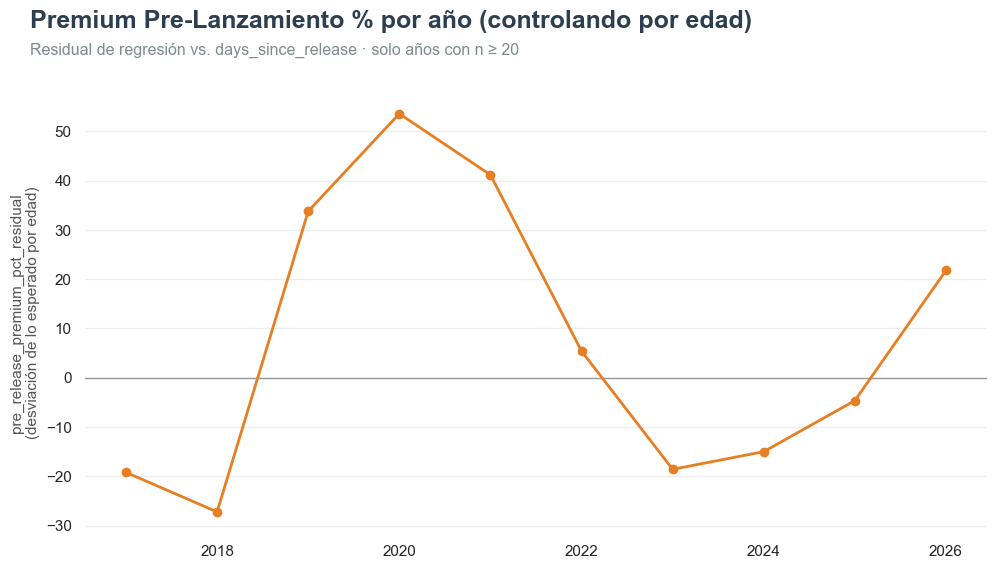

In [104]:
# %%
plot_trend_with_n_residual(df_modelo, 'pre_release_premium_pct_residual',
                            titulo="Premium Pre-Lanzamiento % por año (controlando por edad)",
                            color=COLOR_ACENTO)

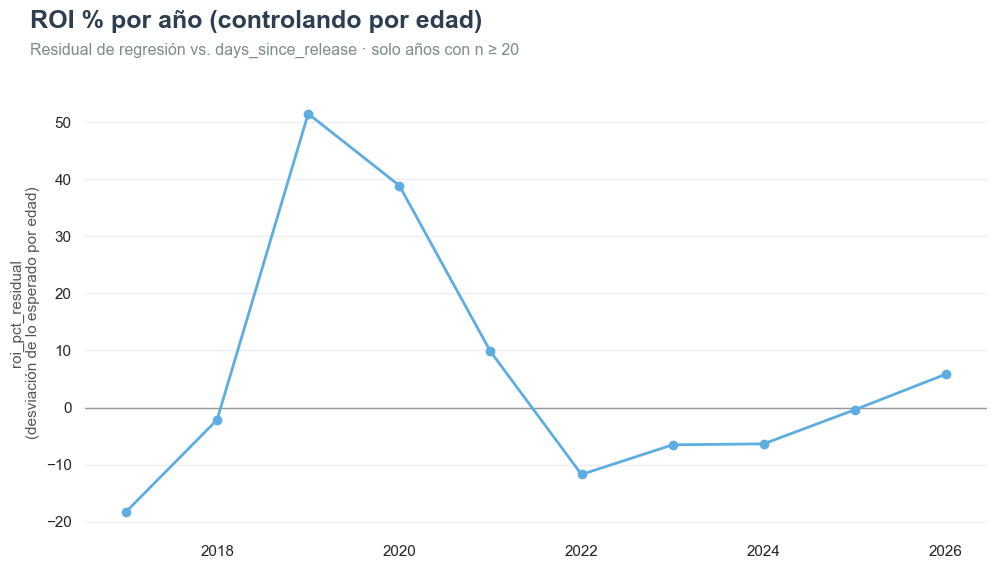

In [105]:
# %%
plot_trend_with_n_residual(df_modelo, 'roi_pct_residual',
                            titulo="ROI % por año (controlando por edad)")

In [106]:
df.columns

Index(['title', 'sales_series', 'retail_price', 'release_date', 'brand',
       'highest_value', 'pre_release_peak', 'roi_pct', 'current_value',
       'is_above_retail', 'pre_release_premium_pct', 'days_to_peak',
       'lowest_value_post_release', 'hype_decay_pct', 'price_volatility',
       'anio', 'days_since_release'],
      dtype='object')

In [ ]:
import scipy.stats as stats
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

def plot_qq_normal(df, num_col, titulo=None, subtitulo=None, color_puntos=None, color_linea='#333333'):
    # 1. Limpieza de datos
    sub = df[num_col].dropna()

    # 2. Configuración del lienzo
    fig, ax = plt.subplots(figsize=(10, 6.5))

    # Títulos con tu estilo editorial
    titulo = titulo or f"Gráfico Q-Q Normal: {num_col}"
    subtitulo = subtitulo or f"n = {len(sub):,} registros · Comparación contra distribución normal teórica"
    fig.text(0.08, 0.96, titulo, fontsize=18, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.915, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    # Rejilla de fondo sutil
    ax.grid(axis='both', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

    # 3. Cálculo del Q-Q Plot usando SciPy
    # osm: cuantiles teóricos, osr: cuantiles ordenados de tus datos
    (osm, osr), (slope, intercept, r) = stats.probplot(sub, dist="norm")

    # Asignar color por defecto si no se pasa uno
    color_puntos = color_puntos or COLOR_PRINCIPAL

    # Dibujar los puntos de los datos
    ax.scatter(osm, osr, color=color_puntos, alpha=0.6, edgecolors='none', s=25, zorder=2, label='Datos')

    # Dibujar la línea de ajuste teórica (45 grados ideal si estuviera estandarizado)
    x_line = [osm.min(), osm.max()]
    y_line = [slope * x + intercept for x in x_line]
    ax.plot(x_line, y_line, color=color_linea, linestyle='--', linewidth=1.5, zorder=3, label='Normal Teórica')

    # Estilizado de ejes
    ax.set_xlabel("Cuantiles Teóricos (Distribución Normal)", fontsize=11, fontweight='medium')
    ax.set_ylabel(f"Cuantiles Observados ({num_col})", fontsize=11, fontweight='medium')

    # Remover bordes (Despine)
    sns.despine(ax=ax, left=True, bottom=True)

    # Ajuste de márgenes para los títulos superiores
    plt.subplots_adjust(top=0.85, left=0.1, right=0.95, bottom=0.15)
    plt.show()

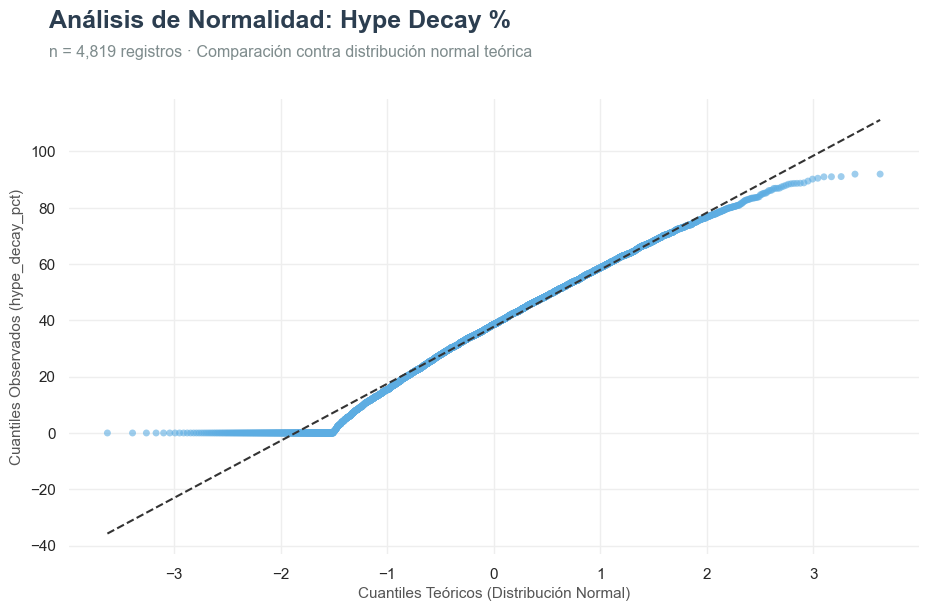

In [ ]:
plot_qq_normal(
    df,
    num_col='hype_decay_pct',
    titulo="Análisis de Normalidad: Hype Decay %",
    color_puntos=COLOR_PRINCIPAL
)

In [ ]:
import numpy as np
import scipy.stats as stats
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.stats.diagnostic import lilliefors

def run_normality_test(df, num_col, titulo=None):
    # 1. Preparación de datos (eliminar nulos)
    data = df[num_col].dropna()
    n = len(data)

    # 2. Ejecutar la prueba de Lilliefors (Kolmogorov-Smirnov modificado)
    # statsmodels nos devuelve el estadístico D y el p-valor corregido
    d_stat, p_value = lilliefors(data, dist='norm')

    # 3. Formatear resultados editoriales
    alpha = 0.05
    resultado_texto = "Rechaza Normalidad (No es Normal)" if p_value < alpha else "No Rechaza Normalidad (Es Normal)"
    color_resultado = "#D32F2F" if p_value < alpha else "#2E7D32" # Rojo si no es normal, Verde si sí.

    # 4. Configuración del gráfico de contraste (Distribución vs Curva Normal Teórica)
    fig, ax = plt.subplots(figsize=(11, 6))

    titulo = titulo or f"Prueba de Normalidad de Kolmogorov-Smirnov (Lilliefors): {num_col}"
    subtitulo = f"n = {n:,} registros  ·  Estadístico D = {d_stat:.4f}  ·  p-valor = {p_value:.4e}"

    fig.text(0.08, 0.96, titulo, fontsize=17, fontweight='bold', color=GRIS_TITULO)
    fig.text(0.08, 0.91, subtitulo, fontsize=11.5, color=GRIS_SUBTITULO)

    ax.grid(axis='y', color='#eeeeee', linestyle='-', linewidth=1, zorder=0)

    # Dibujar la distribución real de hype_decay_pct
    sns.histplot(data, kde=True, stat="density", color=COLOR_PRINCIPAL, alpha=0.4,
                 linewidth=0, line_kws={"linewidth": 2}, ax=ax, zorder=2, label="Datos Observados")

    # Dibujar la distribución normal teórica perfecta con la misma media y desviación estándar
    mu, std = data.mean(), data.std()
    x_axis = np.linspace(data.min(), data.max(), 500)
    ax.plot(x_axis, stats.norm.pdf(x_axis, mu, std), color='#333333', linestyle='--',
            linewidth=2, zorder=3, label=f"Normal Teórica ($\mu$={mu:.2f}, $\sigma$={std:.2f})")

    # Cuadro de texto con la conclusión estadística
    ax.text(0.95, 0.85, f"Resultado ($\\alpha$={alpha}):\n{resultado_texto}",
            transform=ax.transAxes, fontsize=11, fontweight='bold', color=color_resultado,
            bbox=dict(facecolor='white', alpha=0.9, edgecolor='#cccccc', boxstyle='round,pad=0.5'),
            ha='right', va='top', zorder=4)

    # Estilizado final
    ax.set_xlabel(num_col, fontsize=11, fontweight='medium')
    ax.set_ylabel("Densidad", fontsize=11, fontweight='medium')
    ax.legend(loc="upper left", frameon=False)

    sns.despine(ax=ax, left=True, bottom=True)
    plt.subplots_adjust(top=0.84, left=0.1, right=0.95, bottom=0.15)
    plt.show()

    # Retornar las métricas por si necesitas almacenar el resultado en variables
    return {"estadistico_d": d_stat, "p_valor": p_value, "es_normal": p_value >= alpha}

<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\s'
<>:40: SyntaxWarning: invalid escape sequence '\m'
<>:40: SyntaxWarning: invalid escape sequence '\s'
D:\Temp\ipykernel_6872\3195204290.py:40: SyntaxWarning: invalid escape sequence '\m'
  linewidth=2, zorder=3, label=f"Normal Teórica ($\mu$={mu:.2f}, $\sigma$={std:.2f})")
D:\Temp\ipykernel_6872\3195204290.py:40: SyntaxWarning: invalid escape sequence '\s'
  linewidth=2, zorder=3, label=f"Normal Teórica ($\mu$={mu:.2f}, $\sigma$={std:.2f})")


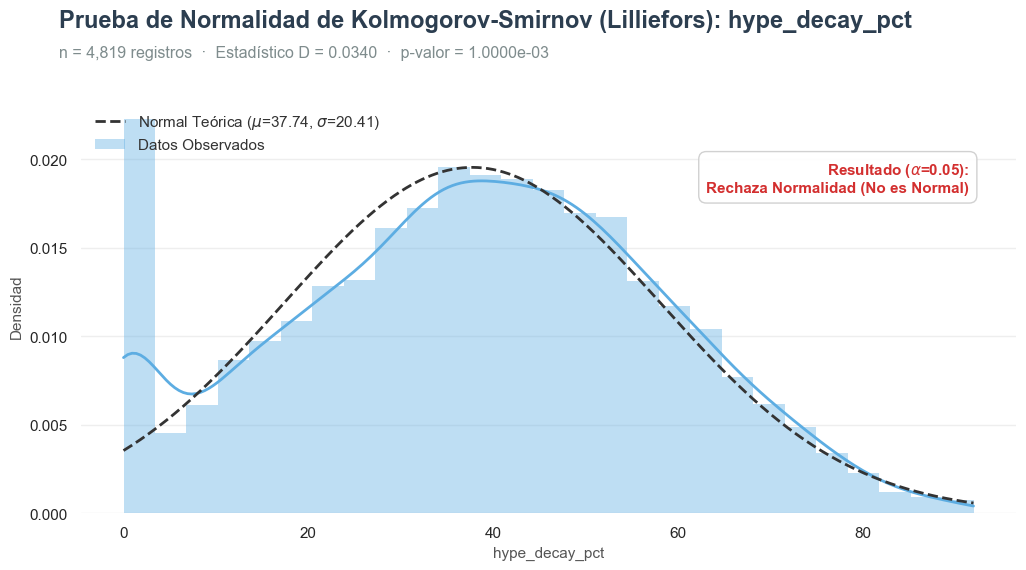

In [114]:
resultados = run_normality_test(df, num_col='hype_decay_pct')